In [205]:
import matplotlib.pyplot as plt
import numpy as np

def plotar_grafo_normalizado(np_array, nome_coluna="Coluna", title="", xlabel="", labelnames=[]):
    # Conta os valores
    contagem = np_array.value_counts()

    # Normaliza
    proporcao = contagem / contagem.sum()

    # Ajusta as labels fornecidas
    if labelnames:
        proporcao.index = labelnames

    # Ordena alfabeticamente os índices
    proporcao = proporcao.sort_index()

    # Plota
    plt.figure(figsize=(10, 6))
    proporcao.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title(title or f'Distribuição da coluna {nome_coluna}')
    plt.xlabel(xlabel or nome_coluna)
    plt.ylabel('Proporção dos Casos')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def checar_nan(df_array, nome_coluna="Coluna"):
    np_array = df_array[nome_coluna]
    total = len(np_array)
    n_nan = np_array.isna().sum()
    perc_nan = (n_nan / total) * 100 if total > 0 else 0
    
    if n_nan > 0:
        print(f"Atenção: A coluna '{nome_coluna}' contém {n_nan} valores NaN.")
        print(f"Isso representa {perc_nan:.2f}% do total de {total} registros.")
    else:
        print(f"A coluna '{nome_coluna}' não contém valores NaN.")
        
    plotar_grafo_normalizado(np_array, nome_coluna=nome_coluna)

    


In [206]:
import pandas as pd
import os

# Diretório onde estão os arquivos CSV
caminho_diretorio = "data/csv_format/"
arquivos_csv = [f for f in os.listdir(caminho_diretorio) if f.endswith(".csv")]
dfs = [pd.read_csv(os.path.join(caminho_diretorio, arquivo), delimiter=',', dtype=str).assign(arquivo=arquivo) for arquivo in arquivos_csv]
df = pd.concat(dfs, ignore_index=True)
df.head()


,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,arquivo
0,0,2,A169,2001-01-04,2001,41,410420,1356,2001-01-04,1961,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
1,1,2,A169,2001-02-20,2001,41,410690,1356,2001-02-20,1974,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
2,2,2,A169,2001-01-12,2001,26,260570,1506,2001-01-12,1960,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
3,3,2,A169,2001-02-23,2001,15,150140,1484,2001-02-23,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
4,4,2,A169,2001-01-05,2001,13,130120,0,2001-01-05,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv


A coluna 'NU_ANO' não contém valores NaN.


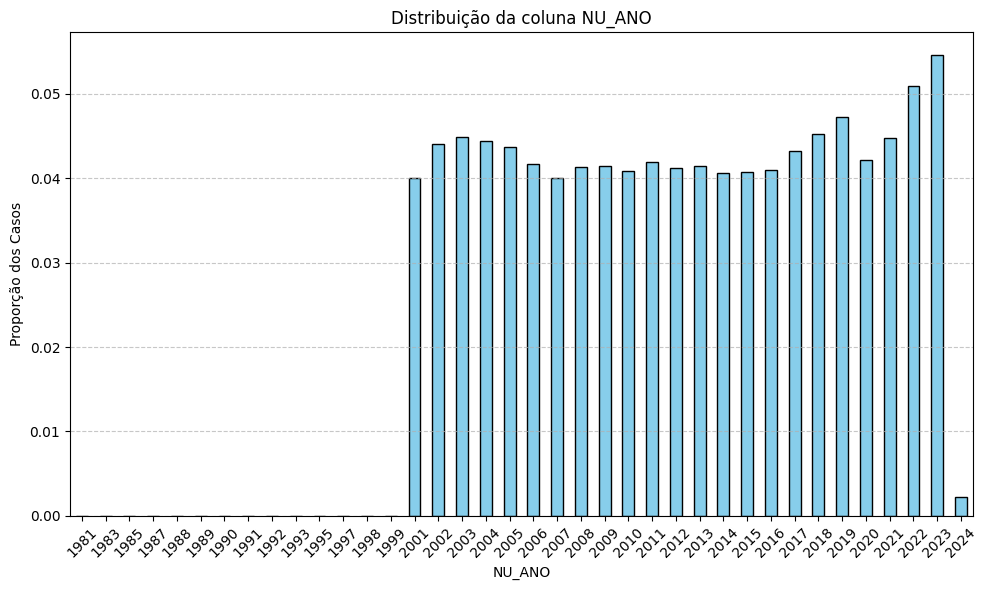

In [207]:
checar_nan(df, nome_coluna="NU_ANO")

In [208]:
df['NU_ANO'] = pd.to_numeric(df['NU_ANO'], errors='coerce')
df_filtra_ano = df[df['NU_ANO'].between(2019, 2023)]

df_filtra_ano.shape

(501562, 99)

In [209]:
df_filtra_ano.head()

,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,arquivo
180124,92859,2,A169,2020-03-18,2020,35,355030,0,2002-02-10,1964,...,1,2,5,7,0,0,0,NaN,NaN,TUBEBR02.csv
715334,86768,2,A169,2019-10-02,2019,35,355030,0,2008-10-01,1962,...,2,1,1,5,0,0,0,NaN,NaN,TUBEBR08.csv
801654,86319,2,A169,2019-01-02,2019,35,355030,0,2009-12-27,1970,...,2,1,1,7,0,0,0,NaN,NaN,TUBEBR09.csv
801655,86320,2,A169,2020-05-26,2020,35,355030,0,2009-06-15,1982,...,2,2,1,7,0,0,0,NaN,NaN,TUBEBR09.csv
887037,85381,2,A169,2019-04-18,2019,35,355030,0,2010-08-19,1983,...,1,1,1,5,1,0,0,NaN,NaN,TUBEBR10.csv


In [210]:
df_filtra_ano.columns

Index(['Unnamed: 0', 'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'NDUPLIC_N', 'IN_VINCULA',
       'DT_DIGITA', 'DT_TRANSUS', 'DT_TRANSDM', 'DT_TRANSSM', 'DT_TRANSRM',
       'DT_TRANSRS', 'DT_TRANSSE', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W',
       'ID_OCUPA_N', 'TRATAMENTO', 'INSTITUCIO', 'RAIOX_TORA', 'TESTE_TUBE',
       'FORMA', 'EXTRAPU1_N', 'EXTRAPU2_N', 'EXTRAPUL_O', 'AGRAVAIDS',
       'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'AGRAVOUTDE',
       'BACILOSC_E', 'BACILOS_E2', 'BACILOSC_O', 'CULTURA_ES', 'CULTURA_OU',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'RIFAMPICIN', 'ISONIAZIDA',
       'ETAMBUTOL', 'ESTREPTOMI', 'PIRAZINAMI', 'ETIONAMIDA', 'OUTRAS',
       'OUTRAS_DES', 'TRAT_SUPER', 'NU_CONTATO', 'DOENCA_TRA', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_

O campo a seguir que sinaliza se houve óbito ou cura:

### 🔹 `SITUA_ENCE` — Situação de encerramento

Conforme o dicionário de dados do SINAN para tuberculose:

| Valor | Descrição                         | 
|-------|-----------------------------------|
| 1     | Cura                              |
| 2     | Abandono                          |
| 3     | Óbito por Tuberculose             |
| 4     | Óbito por outras causas           |
| 5     | Transferência                     |
| 6     | Mudança de diagnóstico            |
| 7     | TB resistente (TB-DR)             |
| 8     | Mudança de esquema terapêutico    |
| 9     | Falência                          |
| 10    | Abandono primário                 |

Atenção: A coluna 'SITUA_ENCE' contém 27209 valores NaN.
Isso representa 5.42% do total de 501562 registros.


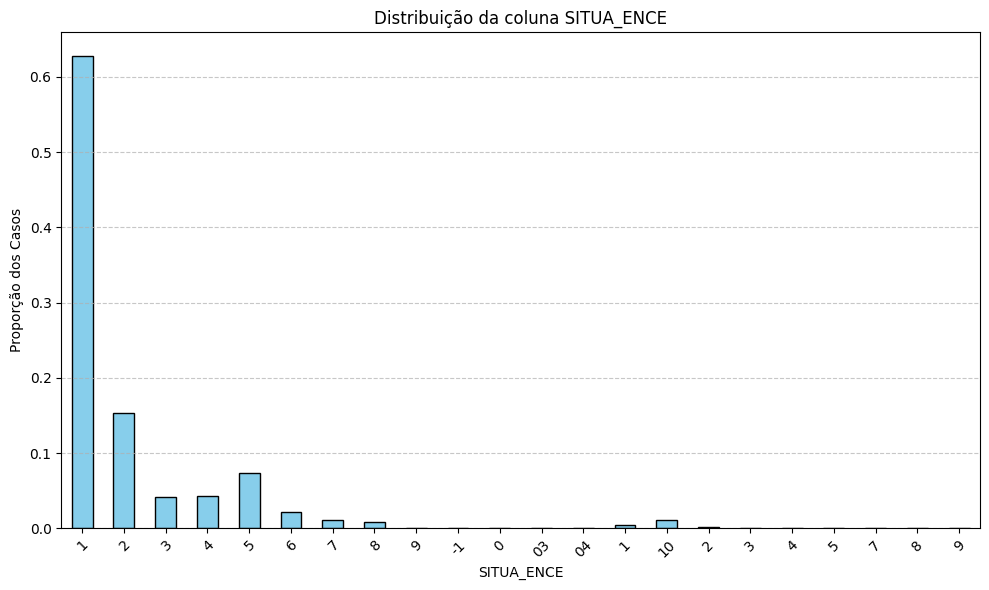

In [211]:
checar_nan(df_filtra_ano, nome_coluna="SITUA_ENCE")


Agora, vamos filtrar para dois casos: Para a coluna igual a 1 ela vai se tornar uma instância de cura de um paciente, para a coluna 3 vai ser considerado os óbitos pela tuberculose.

C:\Users\sarab\AppData\Local\Temp\ipykernel_20104\3673982393.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtra_ano.loc[:, 'SITUACAO_AGRUPADA'] = df_filtra_ano['SITUA_ENCE'].apply(agrupar_situacao)


A coluna 'SITUACAO_AGRUPADA' não contém valores NaN.


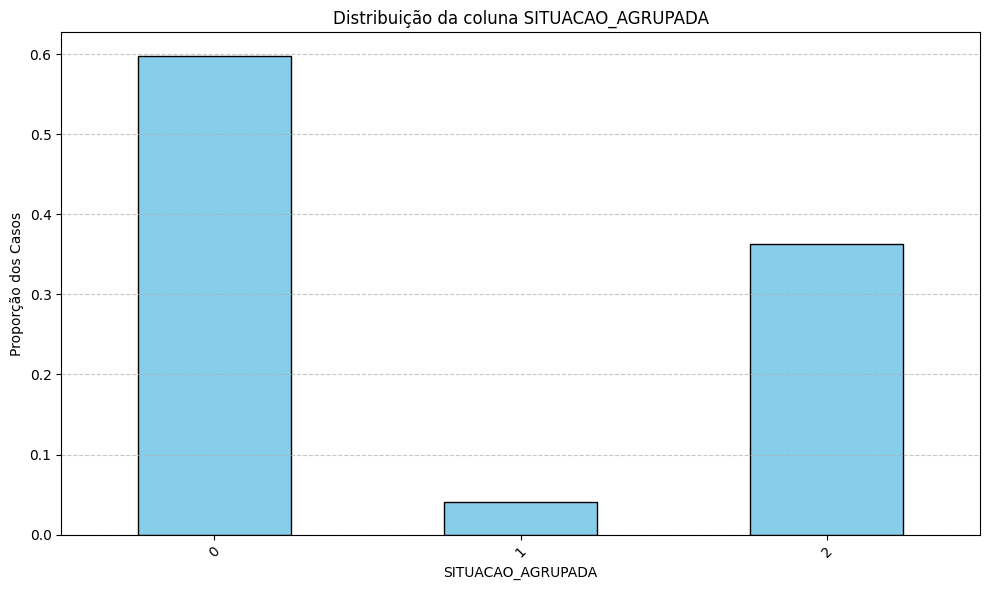

In [212]:
def agrupar_situacao(codigo):
    try:
        if pd.isna(codigo):
            return 2
        codigo = int(float(codigo))  # converte para int, mesmo que venha como float tipo 1.0
        if codigo == 1:
            return 0
        elif codigo == 3:
            return 1
        else:
            return 2
    except:
        print(f'Erro ao processar: {codigo}')
        return 'Outro'


df_filtra_ano.loc[:, 'SITUACAO_AGRUPADA'] = df_filtra_ano['SITUA_ENCE'].apply(agrupar_situacao)

checar_nan(df_filtra_ano, nome_coluna="SITUACAO_AGRUPADA")


Agora, removemos a coluna original e os casos que 'SITUA_ENCE' = 2 

In [213]:
df_filtra_ano = df_filtra_ano.drop(columns=['SITUA_ENCE'])

df_filtra_ano = df_filtra_ano[df_filtra_ano['SITUACAO_AGRUPADA'] != 2]

A coluna 'SITUACAO_AGRUPADA' não contém valores NaN.


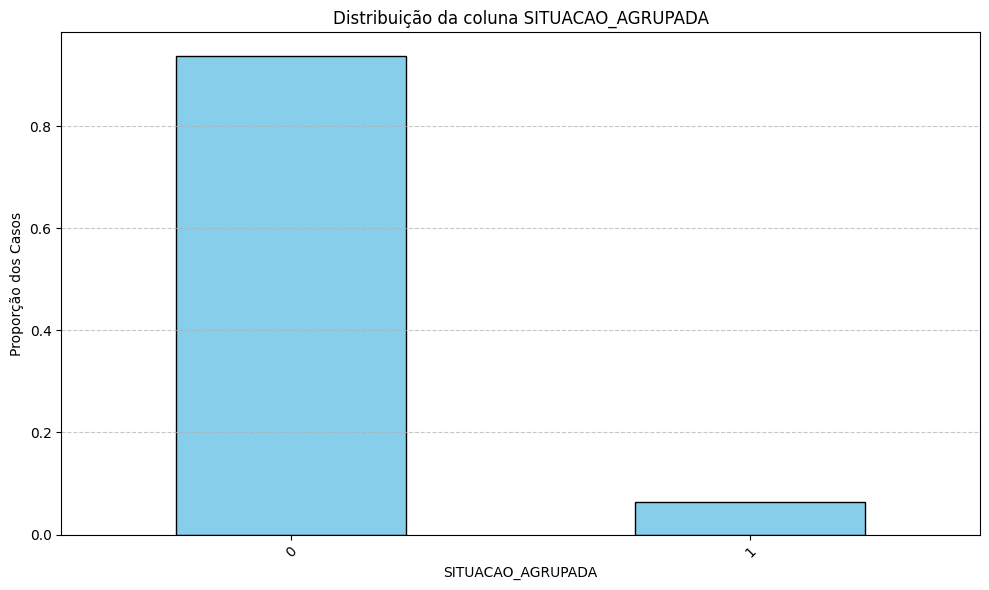

In [214]:
checar_nan(df_filtra_ano, nome_coluna="SITUACAO_AGRUPADA")

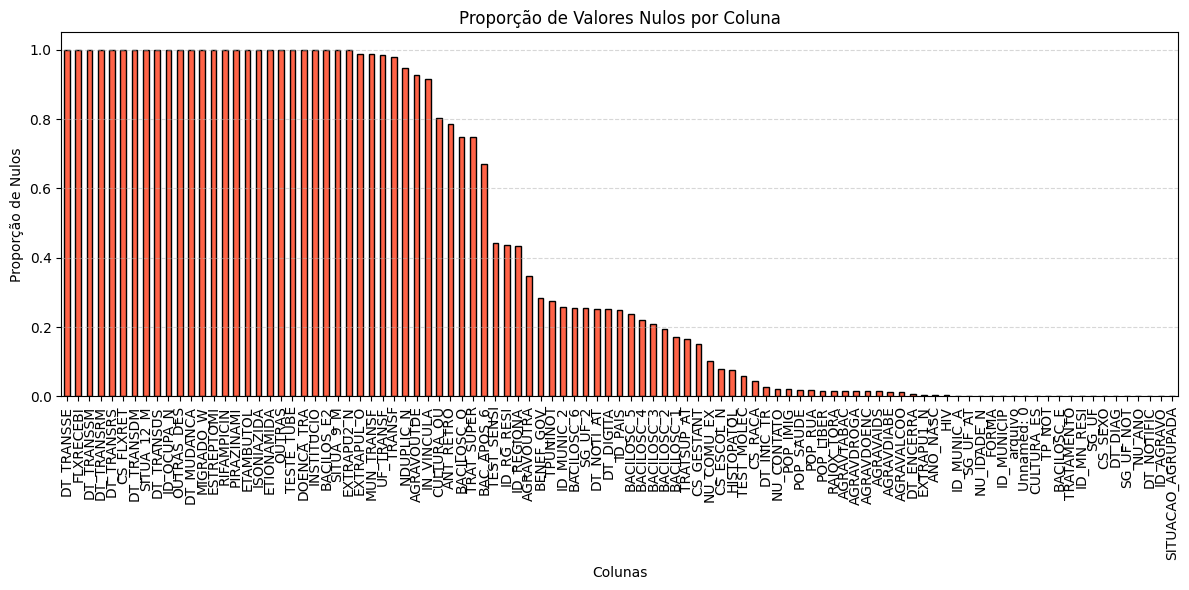

In [215]:
# a gente tentou cortar as colunas com mais componentes nulos

import matplotlib.pyplot as plt

# Calcula a proporção de valores nulos por coluna
null_ratios = df_filtra_ano.isna().mean()

# Plota o histograma (gráfico de barras)
plt.figure(figsize=(12, 6))
null_ratios.sort_values(ascending=False).plot(kind='bar', color='tomato', edgecolor='black')

plt.title('Proporção de Valores Nulos por Coluna')
plt.xlabel('Colunas')
plt.ylabel('Proporção de Nulos')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Vamos remover os casos com mais de 60% de valores vazios, para remover essas colunas com excesso de elementos vazios:

In [216]:
threshold = 0.6

empty_ratio = df_filtra_ano.isna().mean()

columns_to_drop = empty_ratio[empty_ratio > threshold].index

df_cleaned_columns = df_filtra_ano.copy()
df_cleaned_columns = df_cleaned_columns.drop(columns=columns_to_drop)

df_cleaned_columns.head()

,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,POP_RUA,POP_SAUDE,POP_IMIG,BENEF_GOV,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,arquivo,SITUACAO_AGRUPADA
180124,92859,2,A169,2020-03-18,2020,35,355030,0,2002-02-10,1964,...,2,2,2,0,1,2,5,7,TUBEBR02.csv,0
715334,86768,2,A169,2019-10-02,2019,35,355030,0,2008-10-01,1962,...,2,2,2,0,2,1,1,5,TUBEBR08.csv,0
801654,86319,2,A169,2019-01-02,2019,35,355030,0,2009-12-27,1970,...,1,2,2,0,2,1,1,7,TUBEBR09.csv,1
801655,86320,2,A169,2020-05-26,2020,35,355030,0,2009-06-15,1982,...,2,2,3,0,2,2,1,7,TUBEBR09.csv,0
887037,85381,2,A169,2019-04-18,2019,35,355030,0,2010-08-19,1983,...,2,2,2,0,1,1,1,5,TUBEBR10.csv,0


Agora vamos olhar coluna por coluna

**TP_NOT**<br>
1 – Negativa <br>
2 – Individual <br>
3 – Surto <br>
4 – Agregado <br>
Utilidade: Identifica o tipo da notificação

A coluna 'TP_NOT' não contém valores NaN.


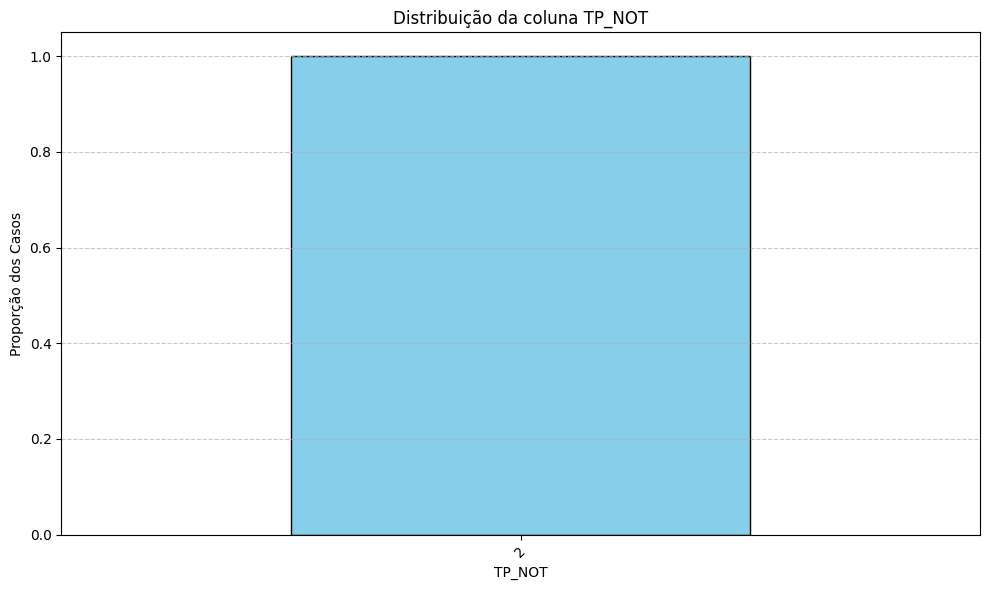

In [217]:
checar_nan(df_filtra_ano, nome_coluna="TP_NOT")

Como há apenas uma categoria relevantes, vamos remover **TP_NOT**

In [218]:
df_cleaned_columns = df_cleaned_columns.drop(columns=["TP_NOT"])

**ID_AGRAVO** <br> 
Tabela de agravos do sistema com códigos (classificação 
internacional de doenças – CID 10) e nomes dos agravos 
classificados como notificação compulsória (nacional, 
estadual ou municipal) e as síndromes (febre hemorragia 
aguda; respiratória aguda; diarréia aguda; sanguinolenta; 
neurológica aguda; insuficiência renal aguda; outras 
síndromes. <br>
Nome e código do agravo notificado 
segundo CID-10 (Centro Colaborador da 
OMS para a Classificação de Doenças 
em Português) <br>

A coluna 'ID_AGRAVO' não contém valores NaN.


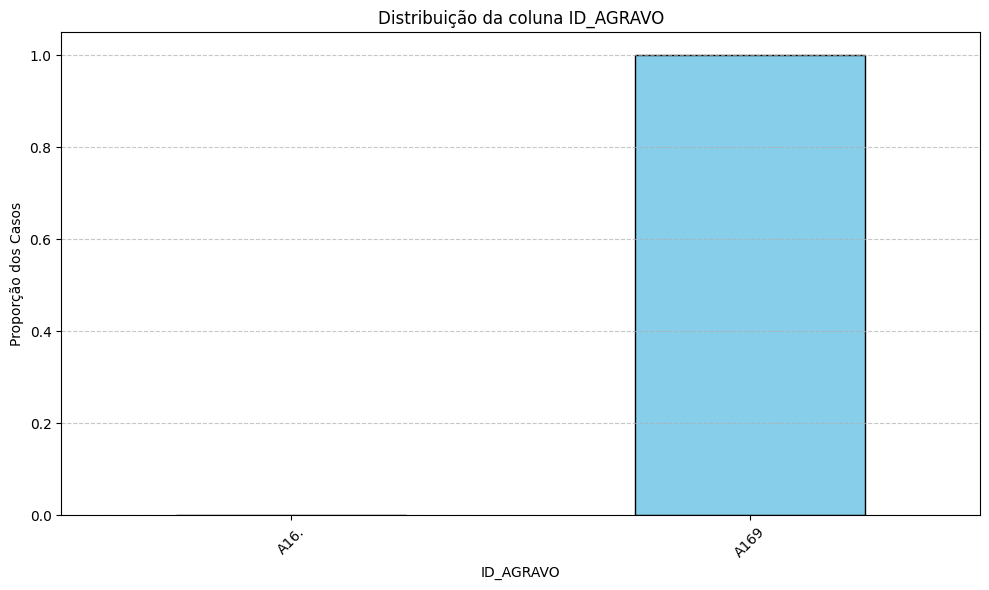

In [219]:
checar_nan(df_cleaned_columns, nome_coluna="ID_AGRAVO")


Como há apenas uma categoria relevantes, vamos remover **ID_AGRAVO**

In [220]:
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns['ID_AGRAVO'] != 'A16.']
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_AGRAVO"])

### Removendo colunas que se referem a exames
**BACILOSC** (E, 1, 2, 3, 4, 5, 6) - varchar2(1) <br>
Baciloscopia
1- Positiva <br>
2- Negativa <br>
3- Não realizada <br>
4- Não se aplica <br>
<br>

**RAIOX_TORA** - varchar2(1) <br>
Radiografia do Tórax <br>
1- Suspeito <br>
2- Normal <br>
3- Outra patologia <br>
4- Não realizado <br>
<br>

**HIV** - varchar2(1) <br>
1- Positivo <br>
2- Negativo <br>
3- Em andamento <br>
4- Não realizado <br>
<br>

**HISTOPATOL** - varchar2(1) <br>
1- Baar Positivo <br>
2- Sugestivo de TB <br>
3- Não sugestivo de TB <br>
4- Em andamento <br>
5- Não realizado <br>
<br>

**CULTURA_ES** - varchar2(1) <br>
Cultura de Escarro
1- Positivo <br>
2- Negativo <br>
3- Em andamento <br>
4- Não realizado <br>
<br>

A coluna 'BACILOSC_E' não contém valores NaN.


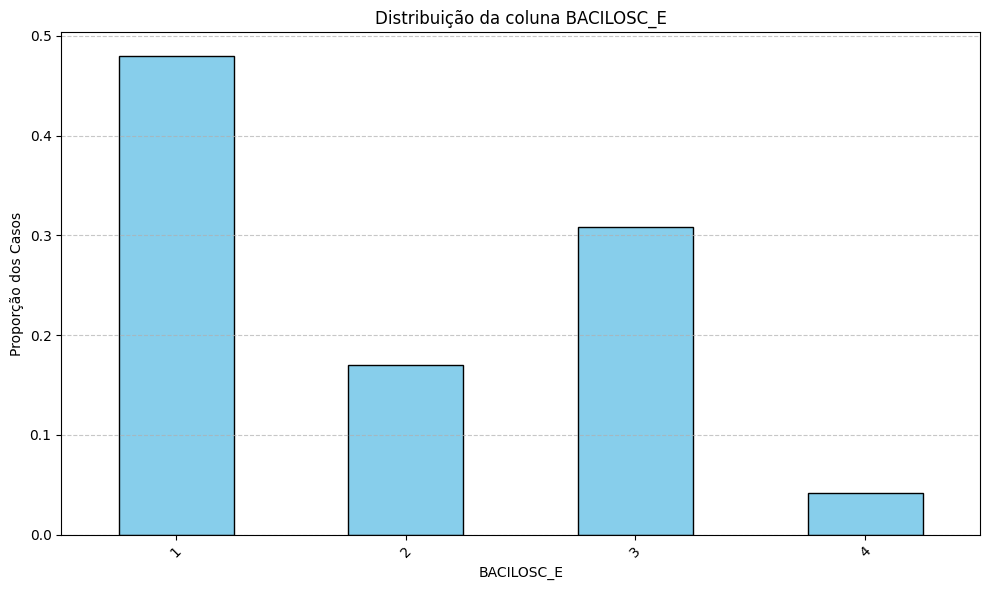

Atenção: A coluna 'BACILOSC_1' contém 54945 valores NaN.
Isso representa 17.18% do total de 319799 registros.


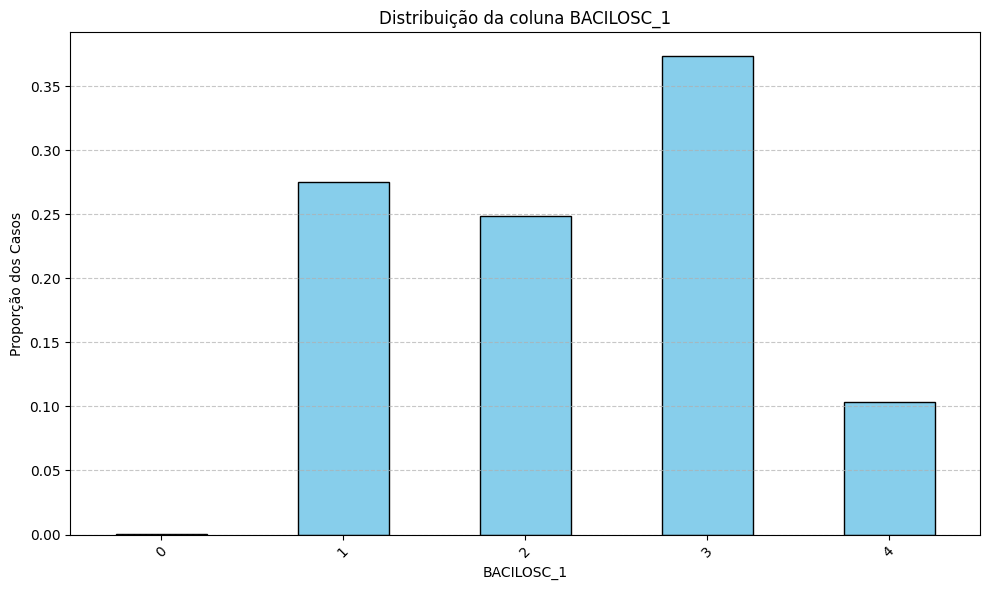

Atenção: A coluna 'BACILOSC_2' contém 62293 valores NaN.
Isso representa 19.48% do total de 319799 registros.


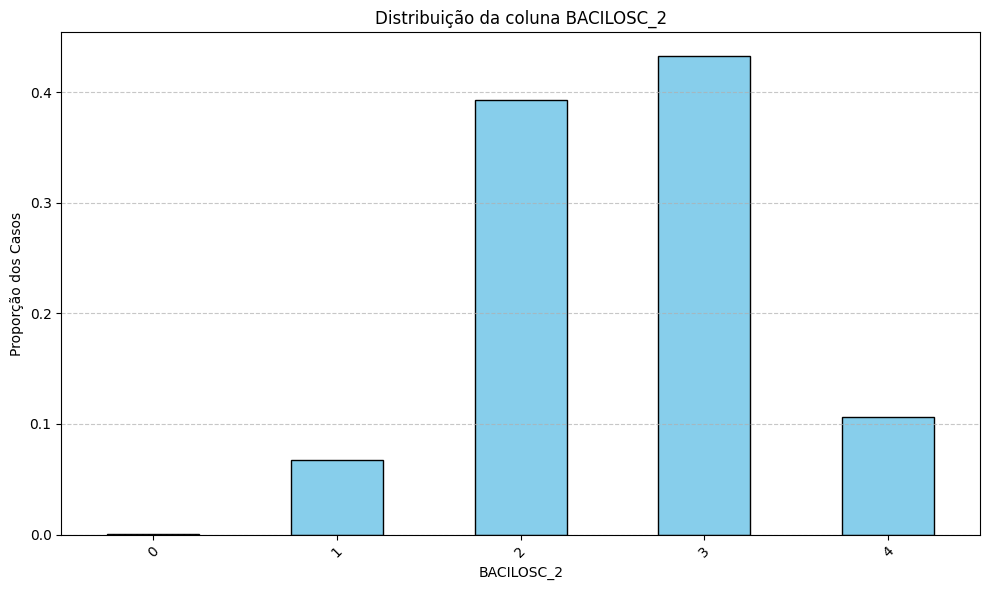

Atenção: A coluna 'BACILOSC_3' contém 67139 valores NaN.
Isso representa 20.99% do total de 319799 registros.


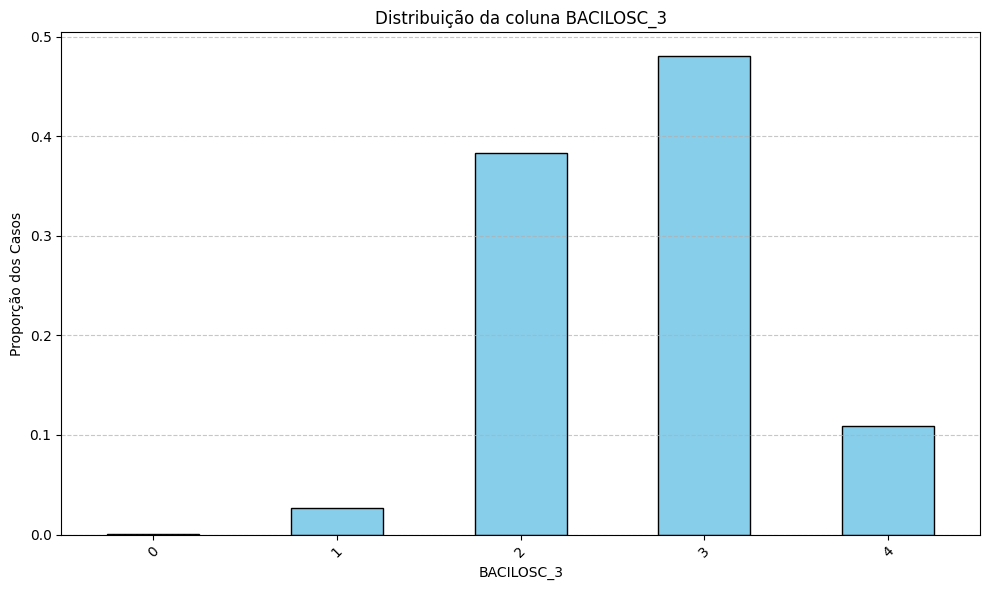

Atenção: A coluna 'BACILOSC_4' contém 70840 valores NaN.
Isso representa 22.15% do total de 319799 registros.


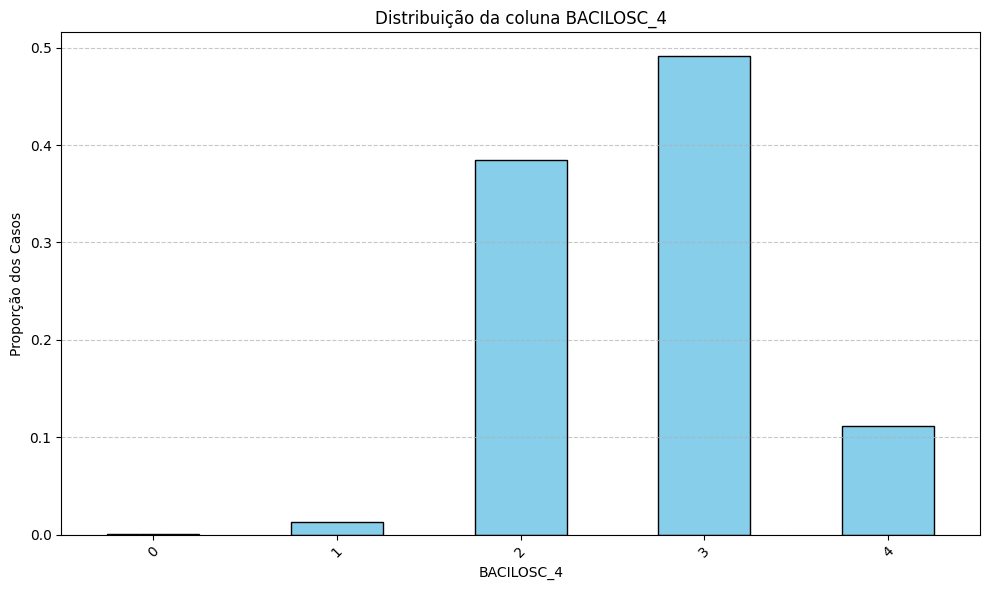

Atenção: A coluna 'BACILOSC_5' contém 76018 valores NaN.
Isso representa 23.77% do total de 319799 registros.


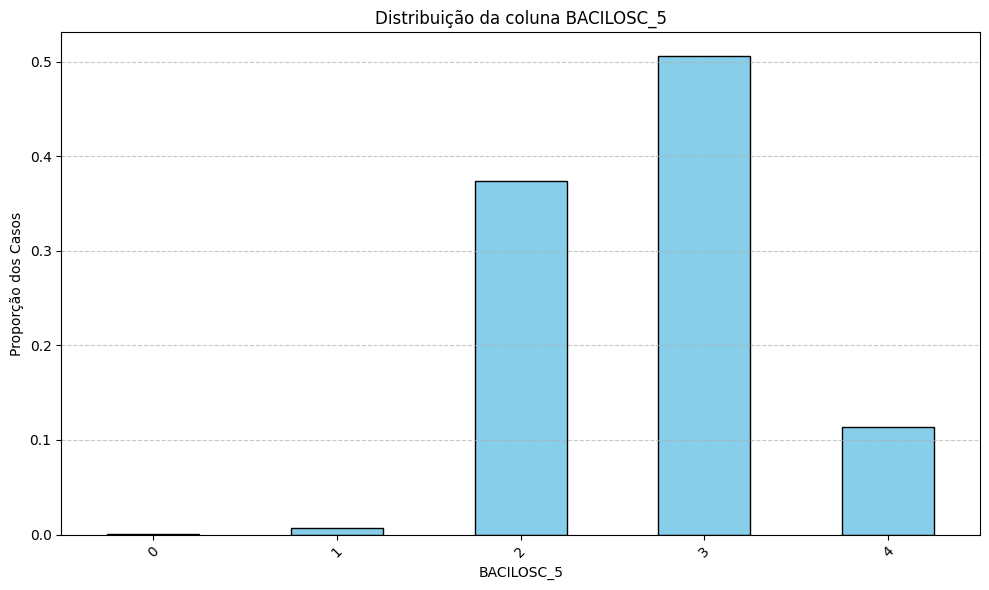

Atenção: A coluna 'BACILOSC_6' contém 81775 valores NaN.
Isso representa 25.57% do total de 319799 registros.


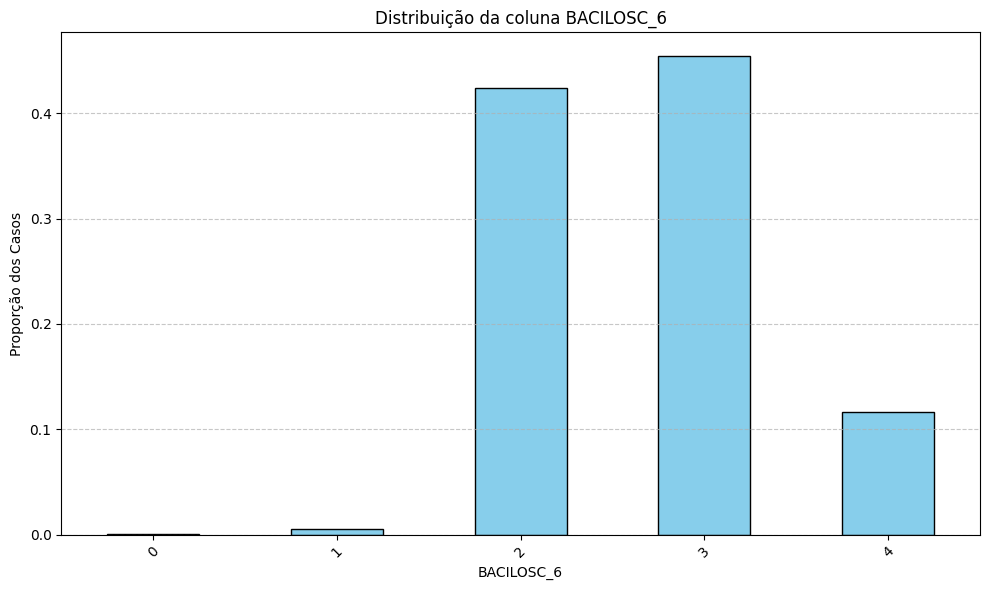

Atenção: A coluna 'RAIOX_TORA' contém 5124 valores NaN.
Isso representa 1.60% do total de 319799 registros.


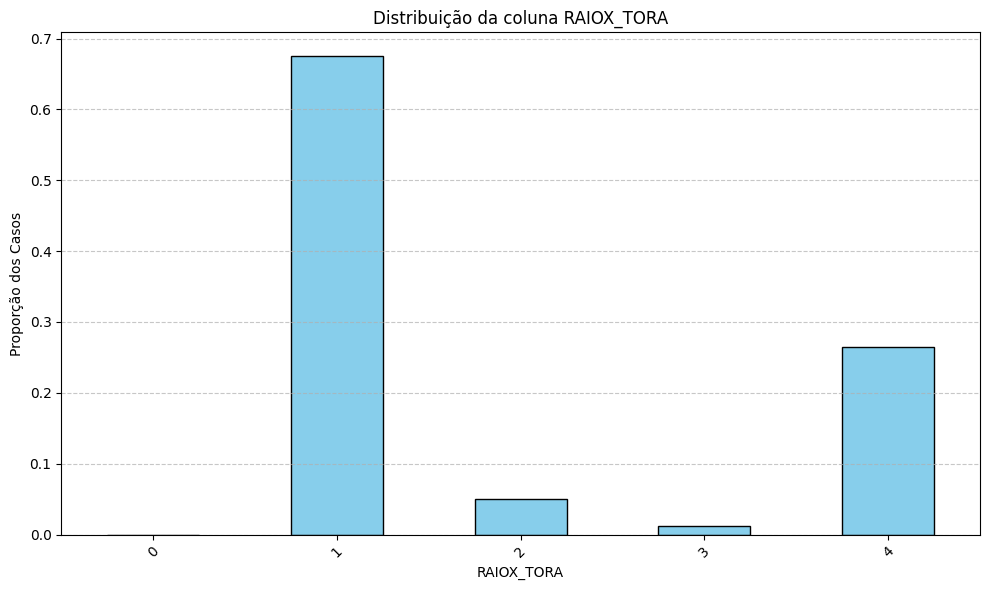

Atenção: A coluna 'HIV' contém 993 valores NaN.
Isso representa 0.31% do total de 319799 registros.


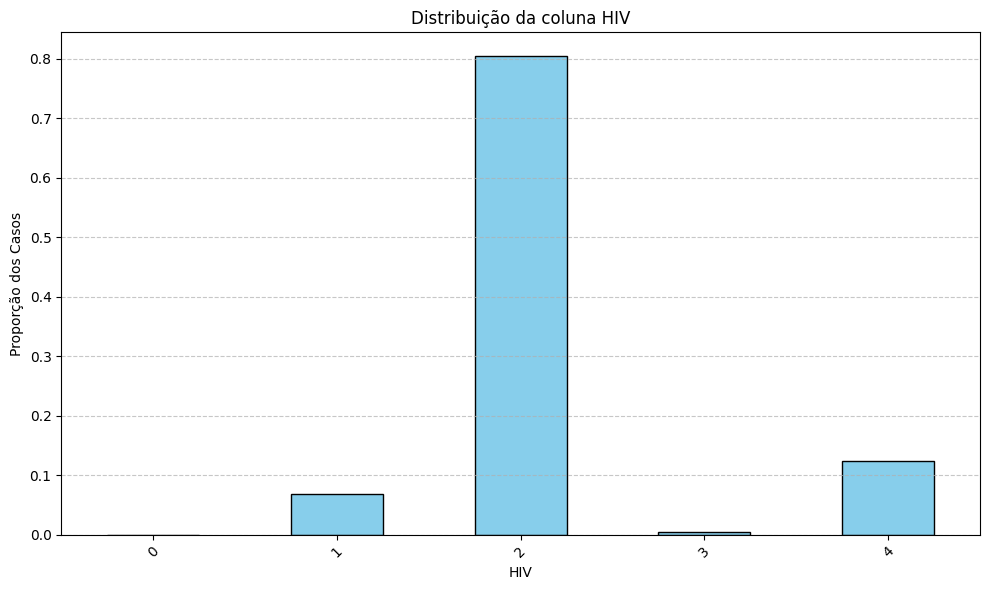

Atenção: A coluna 'HISTOPATOL' contém 24479 valores NaN.
Isso representa 7.65% do total de 319799 registros.


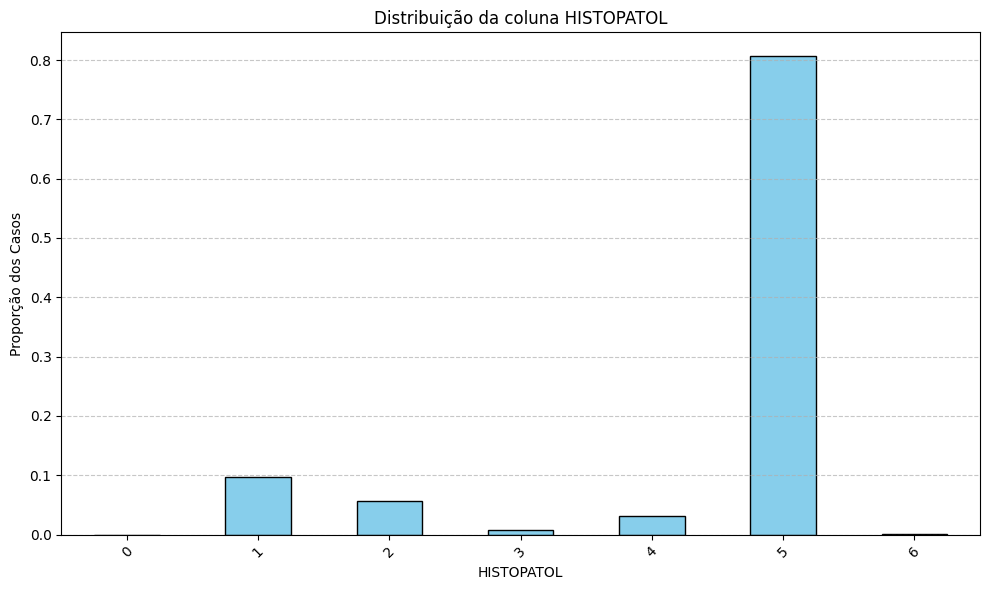

A coluna 'CULTURA_ES' não contém valores NaN.


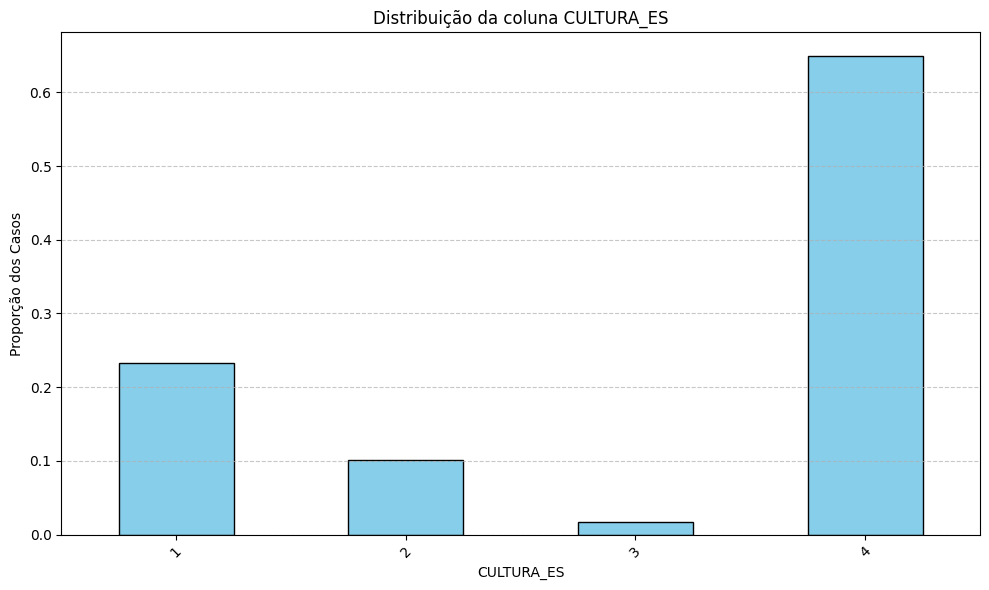

In [221]:
# Lista das colunas a serem removidas
colunas_para_dropar = [
    'BACILOSC_E', 'BACILOSC_1', 'BACILOSC_2', 'BACILOSC_3', 'BACILOSC_4', 'BACILOSC_5', 'BACILOSC_6', 'RAIOX_TORA', 'HIV', 'HISTOPATOL', 
    'CULTURA_ES', 
]

for coluna in colunas_para_dropar:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)
    df_cleaned_columns = df_cleaned_columns.drop(columns=coluna)

**TEST_SENSI** - varchar2(1) <br>
Teste de sensibilidade <br>
1. Resistente somente à Isoniazida <br>
2. Resistente somente à Rifampicina <br>
3. Resistente à Isoniazida e Rifampicina <br>
4. Resistente a outras drogas de 1ªlinha <br>
5. Sensível <br>
6. Em andamento <br>
7. Não realizado <br>

**TEST_MOLEC** - varchar2(1) <br>
Teste molecular rápido (tb) <br>
1. Detectável sensível à Rifampicina <br>
2. Detectável resistente à Rifampicina<br>
3. Não detectável<br>
4. Inconclusivo<br>
5. Não realizado<br>

Atenção: A coluna 'TEST_SENSI' contém 141588 valores NaN.
Isso representa 44.27% do total de 319799 registros.


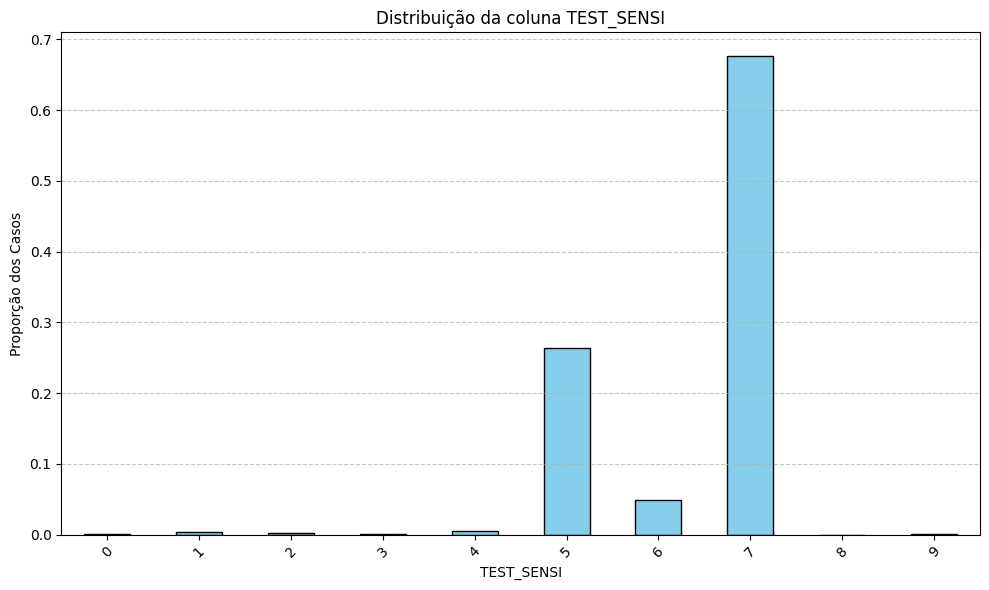

Atenção: A coluna 'TEST_MOLEC' contém 18786 valores NaN.
Isso representa 5.87% do total de 319799 registros.


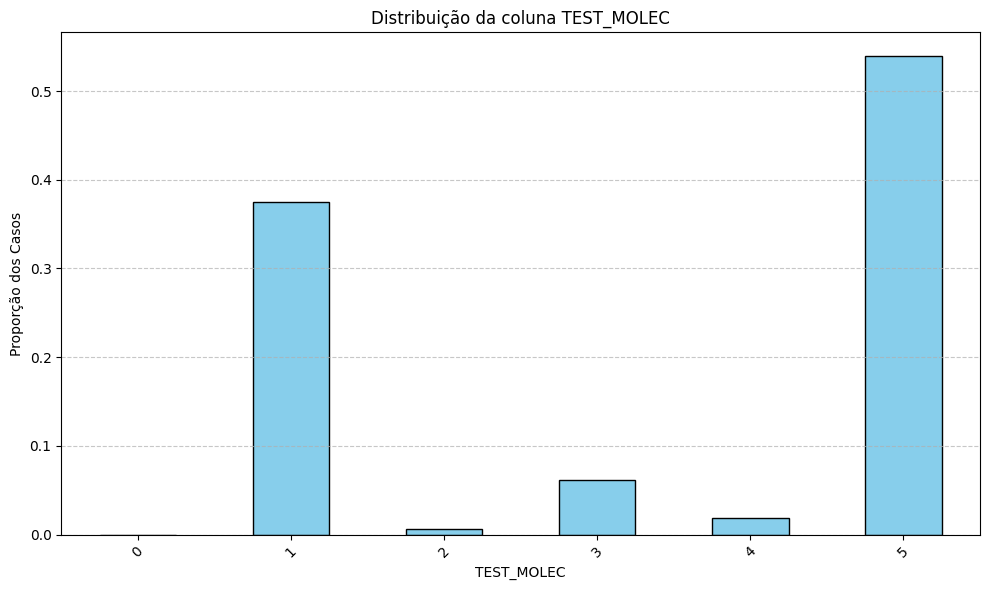

In [222]:
checar_nan(df_cleaned_columns, nome_coluna="TEST_SENSI")
checar_nan(df_cleaned_columns, nome_coluna="TEST_MOLEC")

In [223]:
df_cleaned_columns = df_cleaned_columns.drop(columns="TEST_SENSI")
df_cleaned_columns = df_cleaned_columns.drop(columns="TEST_MOLEC")

In [224]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'DT_NOTIFIC', 'NU_ANO', 'SG_UF_NOT', 'ID_MUNICIP',
       'ID_REGIONA', 'DT_DIAG', 'ANO_NASC', 'NU_IDADE_N', 'CS_SEXO',
       'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'DT_DIGITA', 'TRATAMENTO', 'FORMA',
       'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC',
       'AGRAVOUTRA', 'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT', 'ID_MUNIC_A',
       'DT_NOTI_AT', 'SG_UF_2', 'ID_MUNIC_2', 'TRATSUP_AT', 'NU_COMU_EX',
       'DT_ENCERRA', 'TPUNINOT', 'POP_LIBER', 'POP_RUA', 'POP_SAUDE',
       'POP_IMIG', 'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC', 'arquivo',
       'SITUACAO_AGRUPADA'],
      dtype='object')

**SG_UF_NOT**<br>
UF de Notificação<br> Tabela com Códigos e siglas padronizados pelo IBGE <br>
Sigla da Unidade Federativa onde está 
localizada a unidade de saúde (ou outra 
fonte notificadora) que realizou a 
notificação. A sigla é uma variável que 
está associada ao código na tabela.

A coluna 'SG_UF_NOT' não contém valores NaN.


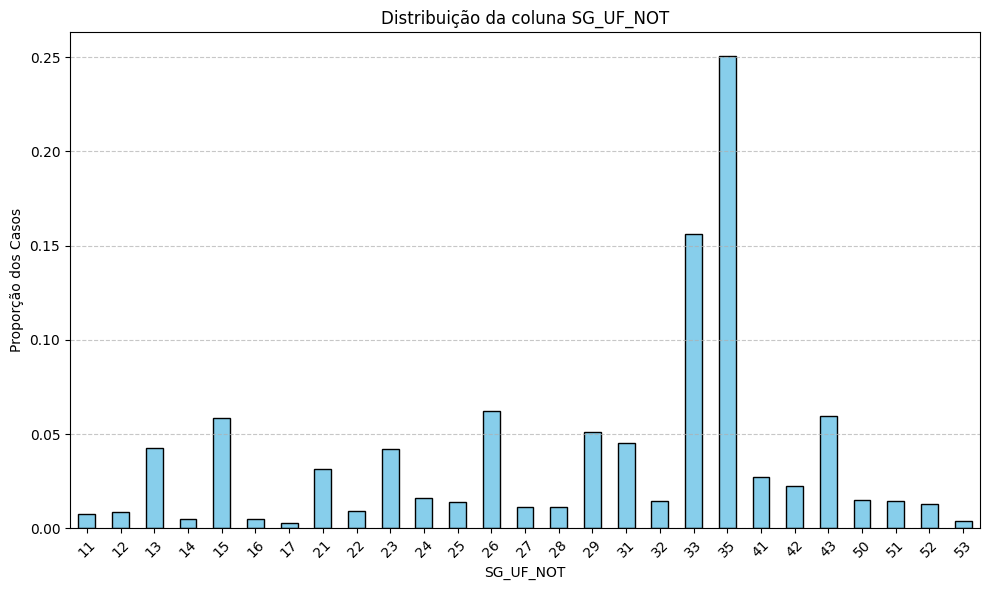

In [225]:
checar_nan(df_cleaned_columns, nome_coluna="SG_UF_NOT")


Vamos remover a coluna **SG_UF_NOT**, para criar **REGIAO**, que vai agrupar por região brasileira ao invés de unidade federativa

A coluna 'REGIAO' não contém valores NaN.


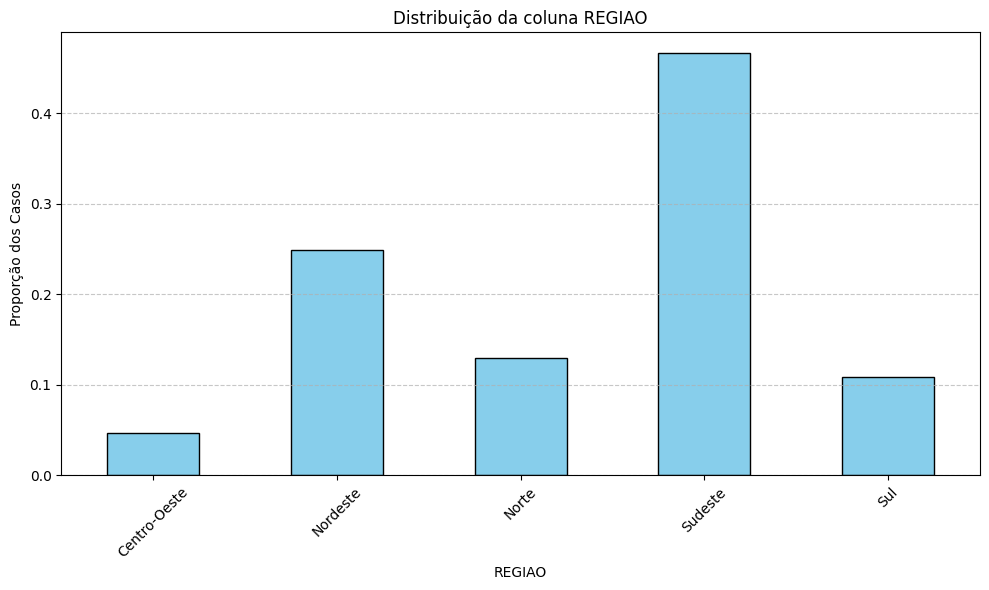

In [226]:
# Dicionário de UFs por região
regioes = {
    # Norte
    12: 'Norte', 16: 'Norte', 13: 'Norte', 11: 'Norte', 14: 'Norte',
    15: 'Norte', 17: 'Norte',

    # Nordeste
    21: 'Nordeste', 22: 'Nordeste', 23: 'Nordeste', 24: 'Nordeste',
    25: 'Nordeste', 26: 'Nordeste', 27: 'Nordeste', 28: 'Nordeste',
    29: 'Nordeste',

    # Centro-Oeste
    50: 'Centro-Oeste', 51: 'Centro-Oeste', 52: 'Centro-Oeste', 53: 'Centro-Oeste',

    # Sudeste
    31: 'Sudeste', 32: 'Sudeste', 33: 'Sudeste', 35: 'Sudeste',

    # Sul
    41: 'Sul', 42: 'Sul', 43: 'Sul'
}

# Cria uma nova coluna com o nome da região
df_cleaned_columns["SG_UF_NOT"] = df_cleaned_columns["SG_UF_NOT"].astype(int)
df_cleaned_columns["REGIAO"] = df_cleaned_columns["SG_UF_NOT"].map(regioes)

df_cleaned_columns = df_cleaned_columns.drop(columns=['SG_UF_NOT'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['SG_UF'])

checar_nan(df_cleaned_columns, nome_coluna="REGIAO")


**ID_MUNICIP** <br>
Município de Notificação <br>Tabela com Código e nome dos municípios do cadastro do 
IBGE (tabela municipi.dbf) <br>
Código do município onde está 
localizada a unidade de saúde (ou outra 
fonte notificadora) que realizou a 
notificação. O nome está associado ao 
código na tabela de municípios.

Atenção: A coluna 'ID_MUNICIP' contém 1 valores NaN.
Isso representa 0.00% do total de 319799 registros.


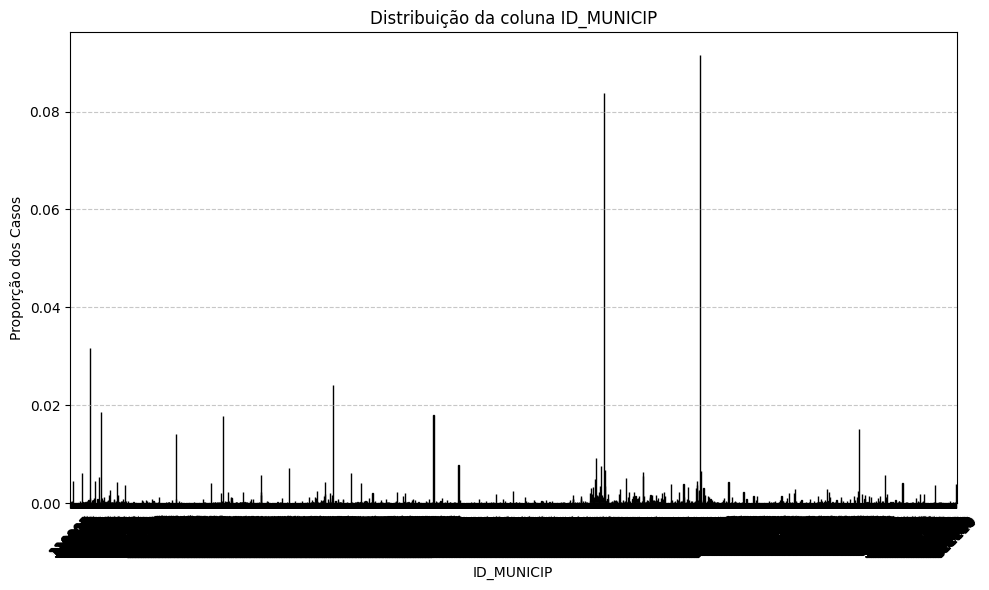

In [227]:
checar_nan(df_cleaned_columns, nome_coluna="ID_MUNICIP")

Vamos dar drop em **ID_MUNICIP**,e as outras colunas de municipio, porque já temos a coluna **REGIAO** para representar dados geográficos, e por **ID_MUNICIP** ter granularidade demais.

In [228]:
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_MUNICIP"])
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_MUNIC_2"])
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_MUNIC_A"])
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_REGIONA"])

**NU_IDADE_N**<br>Idade <br>
A composição da variável obedece ao seguinte critério: 1o 
dígito:<br> <br>
1 – Hora <br>
2 – Dia <br>
3 – Mês <br>
4 – Ano <br>
 <br>
Ex: 3009 – nove meses, 4018 – dezoito anos <br>
Quando não há data de nascimento a 
idade deve ser digitada segundo 
informação fornecida pelo paciente 
como aquela referida por ocasião da 
data dos primeiros sintomas ou na falta 
desse dado é registrada a idade 
aparente. <br>

Realizando a transformação para encontrar uma coluna de idade:

Atenção: A coluna 'NU_IDADE_N' contém 91 valores NaN.
Isso representa 0.03% do total de 319799 registros.


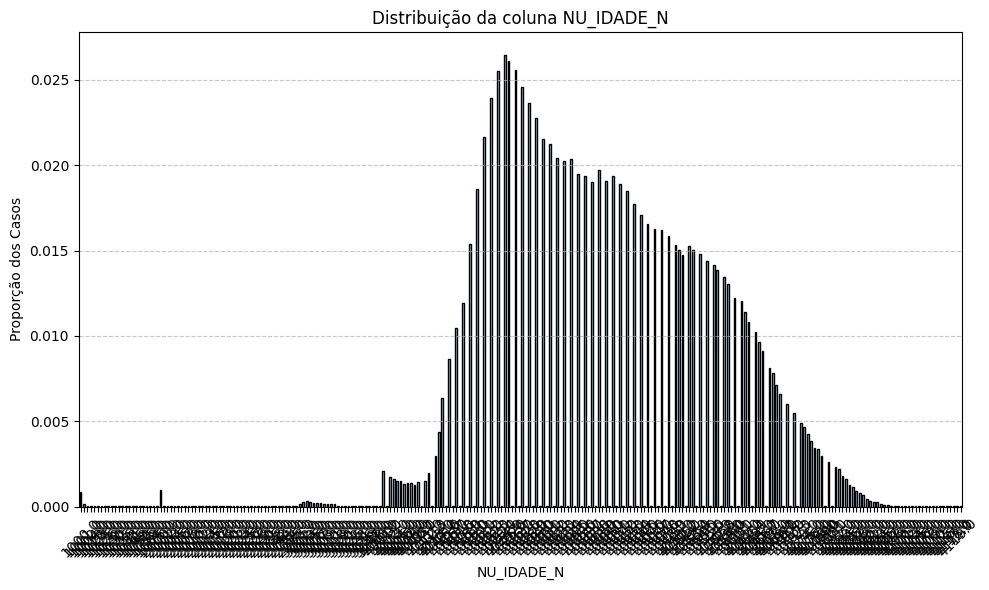

In [229]:
checar_nan(df_cleaned_columns, nome_coluna="NU_IDADE_N")

In [230]:
import numpy as np

# Função para converter idade para anos
def idade_em_anos(valor):
    try:
        valor = int(float(valor))  # Ex: 4023.0 -> 4023
        unidade = valor // 1000    # 4 em 4023 (anos)
        quantidade = valor % 1000  # 23 em 4023

        if unidade == 1:  # horas
            return quantidade / (24 * 365)
        elif unidade == 2:  # dias
            return quantidade / 365
        elif unidade == 3:  # meses
            return quantidade / 12
        elif unidade == 4:  # anos
            return quantidade
        else:
            return np.nan
    except:
        return np.nan

df_cleaned_columns["IDADE_ANOS"] = df_cleaned_columns["NU_IDADE_N"].apply(idade_em_anos)
df_cleaned_columns = df_cleaned_columns.drop(columns=["NU_IDADE_N"])

df_cleaned_columns["IDADE_ANOS"] = df_cleaned_columns["IDADE_ANOS"].round().astype("Int64")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["IDADE_ANOS"].between(16, 110)]

print(f"Total final de registros com idade válida: {len(df_cleaned_columns)}")

Total final de registros com idade válida: 307851


In [231]:
df_cleaned_columns["IDADE_ANOS"].value_counts()

IDADE_ANOS
24     8466
25     8345
26     8181
23     8164
27     7871
       ... 
106       1
108       1
105       1
107       1
110       1
Name: count, Length: 95, dtype: Int64

A coluna 'IDADE_ANOS' não contém valores NaN.


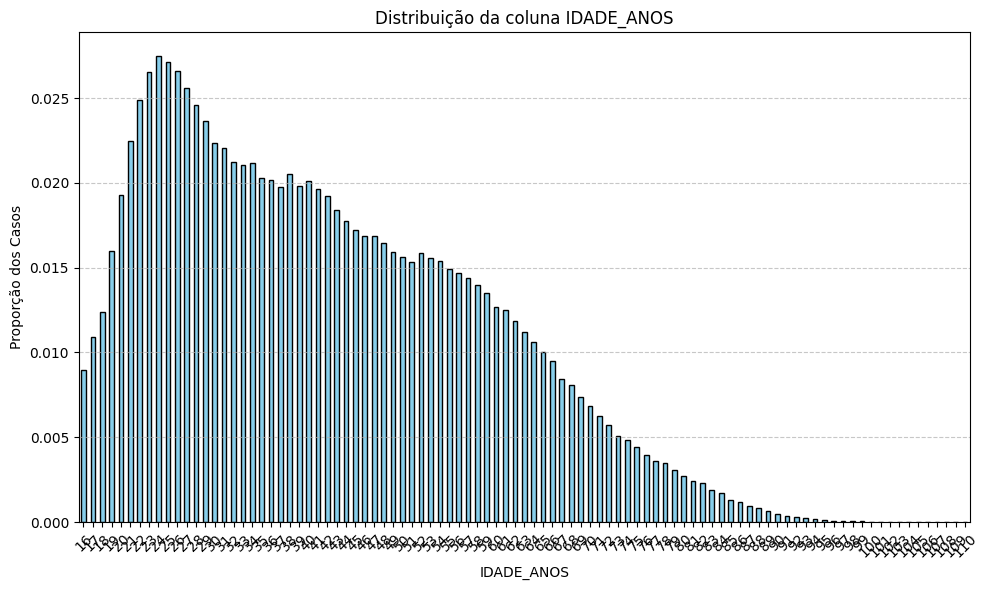

In [232]:
checar_nan(df_cleaned_columns, nome_coluna="IDADE_ANOS")

Vamos dar drop no **ANO_NASC**, pois **IDADE_ANOS** é análogo

In [233]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['ANO_NASC'])

**CS_SEXO**<br><br>
M – Masculino <br>
F – Feminino <br>
I – Ignorado <br> <br>
<br>Sexo do paciente 


A coluna 'CS_SEXO' não contém valores NaN.


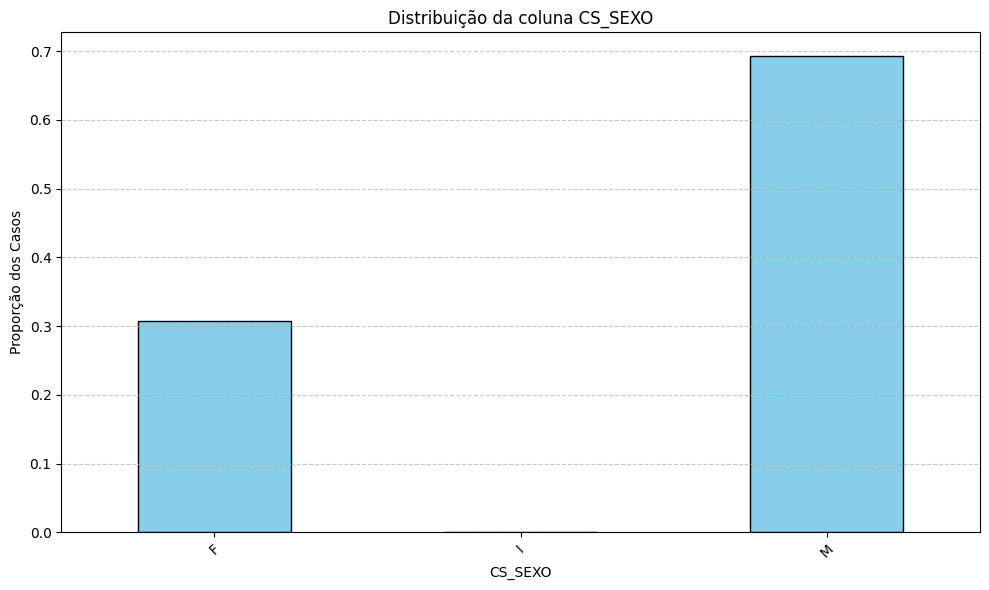

In [234]:
checar_nan(df_cleaned_columns, nome_coluna="CS_SEXO")

Vamos remover apenas os índices indeteminados (I)

In [235]:
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["CS_SEXO"] != "I"]

**CS_GESTANT** <br> 
Gestante <br> <br> 
1 – 1º Trimestre <br> 
2 – 2º Trimestre <br> 
3 – 3º Trimestre <br> 
4 – Idade gestacional ignorada <br> 
5 – Não <br> 
6 – Não se aplica <br> 
9 – Ignorado <br> <br> 
Idade gestacional da paciente.

Atenção: A coluna 'CS_GESTANT' contém 47996 valores NaN.
Isso representa 15.59% do total de 307820 registros.


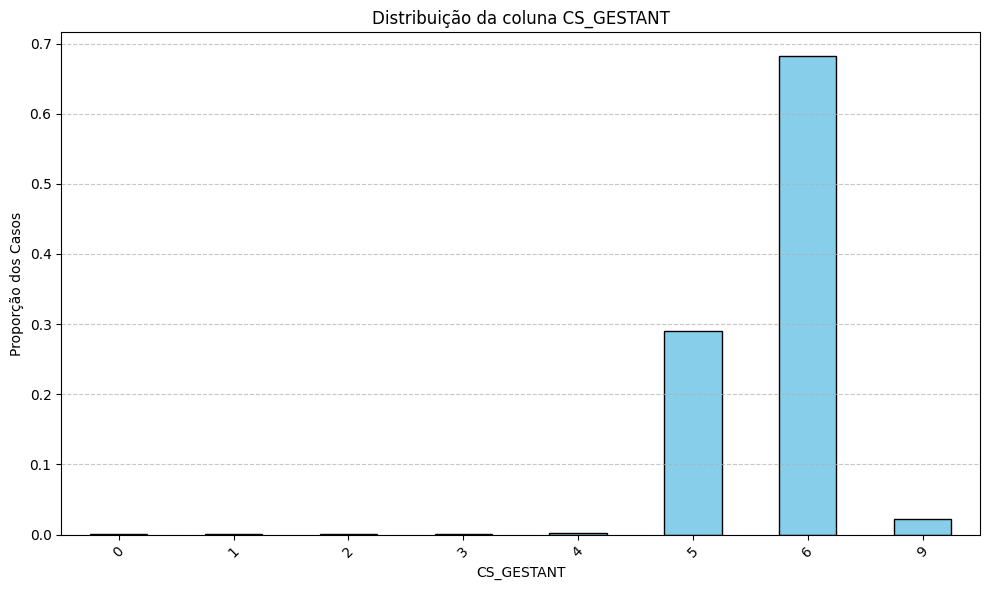

In [236]:
checar_nan(df_cleaned_columns, nome_coluna="CS_GESTANT")

Vamos remover **CS_GESTANT**, pois claramente não há casos positivos para gravidez o suficiente (quase 100% são Não, não se aplica ou Ignorado)

In [237]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['CS_GESTANT'])

**CS_RACA**<br>
Raça/Cor <br>
1 – Branca <br> 
2 – Preta <br>
3 – Amarela <br>
4 – Parda <br>
5 – Indígena <br>
9 – Ignorado <br> <br>

Atenção: A coluna 'CS_RACA' contém 14223 valores NaN.
Isso representa 4.62% do total de 307820 registros.


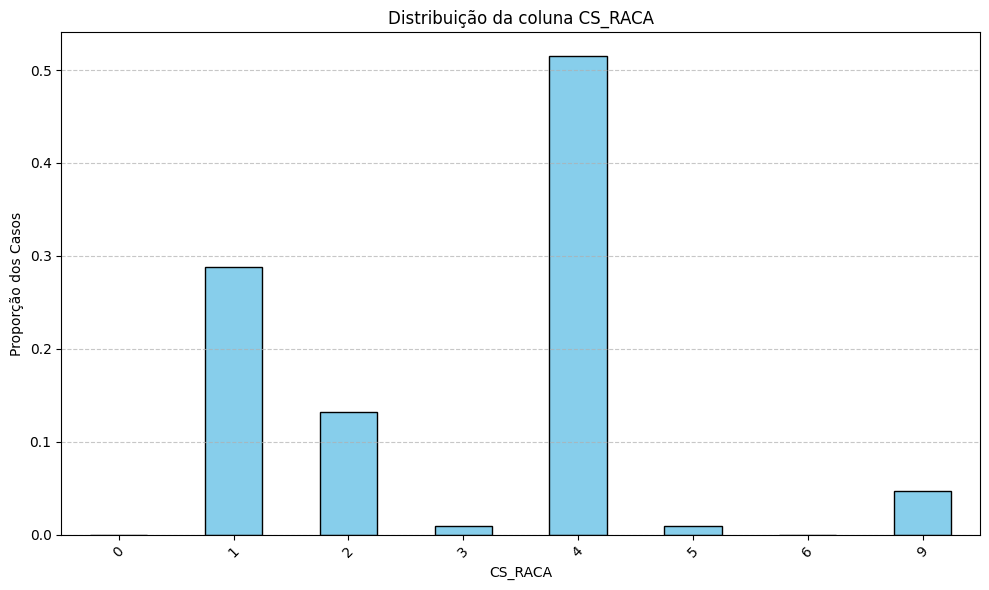

In [238]:
checar_nan(df_cleaned_columns, "CS_RACA")

Em **CS_RACA** vamos selecionar apenas casos de pessoas brancas, pretas e pardas, por serem maiores que 10% do total.

In [239]:
df_cleaned_columns["CS_RACA"].value_counts()

CS_RACA
4    151168
1     84460
2     38781
9     13669
5      2800
3      2715
0         3
6         1
Name: count, dtype: int64

In [240]:
df_cleaned_columns["CS_RACA"] = pd.to_numeric(df_cleaned_columns["CS_RACA"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["CS_RACA"].isin([1, 2, 4])]
df_cleaned_columns['CS_RACA'] = df_cleaned_columns['CS_RACA'].astype(int)

A coluna 'CS_RACA' não contém valores NaN.


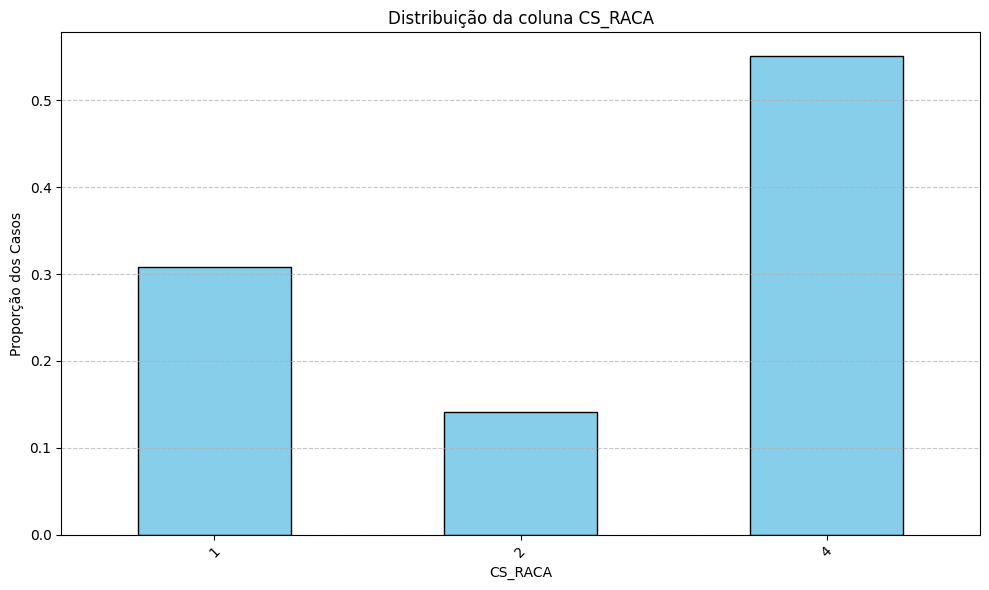

In [241]:
checar_nan(df_cleaned_columns, "CS_RACA")

**ID_PAIS**<br>País (se residente fora do Brasil)<br>Tabela com código e descrição de paises.  País onde residia o paciente por ocasião 
da notificação

In [242]:
df_cleaned_columns["ID_PAIS"].value_counts()

ID_PAIS
1    213195
0        36
7         2
6         2
Name: count, dtype: int64

Vamos remover **ID_PAIS**, visto que não há valores relevantes

In [243]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['ID_PAIS'])

**CS_ESCOL_N**<br>
Escolaridade 
<br><br>
0 – Analfabeto  <br>
1 – 1ª a 4ª série incompleta do EF <br>
2 – 4ª série completa do EF (antigo 1° grau) <br>
3 – 5ª à 8ª série incompleta do EF (antigo ginásio ou 1° grau) <br>
4 – Ensino fundamental completo (antigo ginásio ou 1° grau) <br>
5 – Ensino médio incompleto (antigo colegial ou 2° grau) <br>
6 – Ensino médio completo (antigo colegial ou 2° grau) <br>
7 – Educação superior incompleta  <br>
8 – Educação superior completa  <br>
9 – Ignorado <br>
10 – Não se aplica <br><br>
Série e grau que a pessoa está 
frequentando ou frequentou 
considerando a última série concluída 
com aprovação ou grau de instrução do 
paciente por ocasião da notificação. 


Atenção: A coluna 'CS_ESCOL_N' contém 18208 valores NaN.
Isso representa 6.64% do total de 274409 registros.


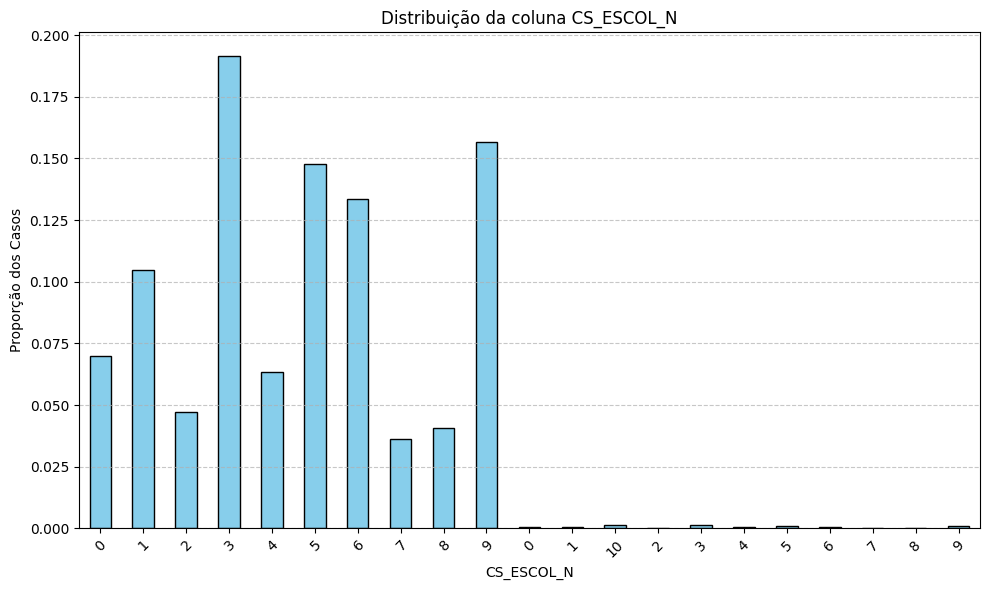

In [244]:
checar_nan(df_cleaned_columns, "CS_ESCOL_N")

Vamos fazer a separação em: <br><br>

1. Esino básico incompleto <br>
2. Ensino básico completo  <br>
3. Ensino médio completo <br>
4. Ensino superior completo <br>

In [245]:
# 1. Converte para numérico e trata erros
df_cleaned_columns["CS_ESCOL_N"] = pd.to_numeric(df_cleaned_columns["CS_ESCOL_N"], errors="coerce")

# 2. Filtra apenas os valores válidos (os que têm uma categoria definida)
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["CS_ESCOL_N"].isin([0, 1, 2, 3, 4, 6, 8])]

# 3. Agora sim, aplica a categorização
def categorizar_escolaridade(valor):
    if valor in [0, 1, 2, 3]:
        return 0
    elif valor == 4:
        return 1
    elif valor == 6:
        return 2
    elif valor == 8:
        return 3

df_cleaned_columns["ESCOL_CATEGORIZADA"] = df_cleaned_columns["CS_ESCOL_N"].apply(categorizar_escolaridade)


A coluna 'ESCOL_CATEGORIZADA' não contém valores NaN.


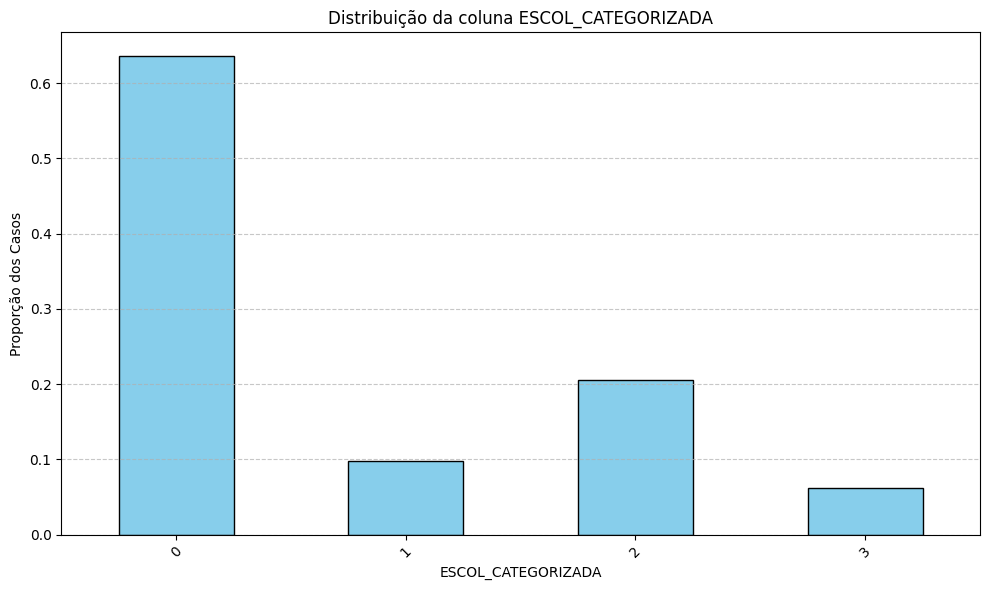

In [246]:
checar_nan(df_cleaned_columns, "ESCOL_CATEGORIZADA")

In [247]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['CS_ESCOL_N'])

**TRATAMENTO** <br>
<br>Preencher com o 
código 
correspondente ao 
tipo de entrada do 
paciente na unidade 
de saúde. O “caso 
novo” é todo paciente 
que nunca se 
submeteu ao 
tratamento de tuberculose, ou o fez 
por até 30 dias. Os 
retratamentos podem 
acontecer por: 
“recidiva” após cura e 
“reingresso após 
abandono”, quando 
ocorre interrupção de 
um tratamento por 
mais de 30 dias. O 
“Não sabe” deve ser 
preenchido apenas 
quando esgotadas as 
possibilidades de 
investigação das 
entradas anteriores do 
paciente. A 
“transferência” se 
refere ao paciente 
encaminhado de outro 
serviço para 
seguimento do 
tratamento. Os casos 
com entrada “Pós-
óbito” são aqueles 
identificados 
tardiamente, ou seja, 
no momento ou após 
a morte do paciente<br>
1. Caso Novo <br>
2. Recidiva <br>
3. Reingresso após Abandono <br>
4. Não Sabe <br>
5. Transferência <br>
6. Pós-óbito

A coluna 'TRATAMENTO' não contém valores NaN.


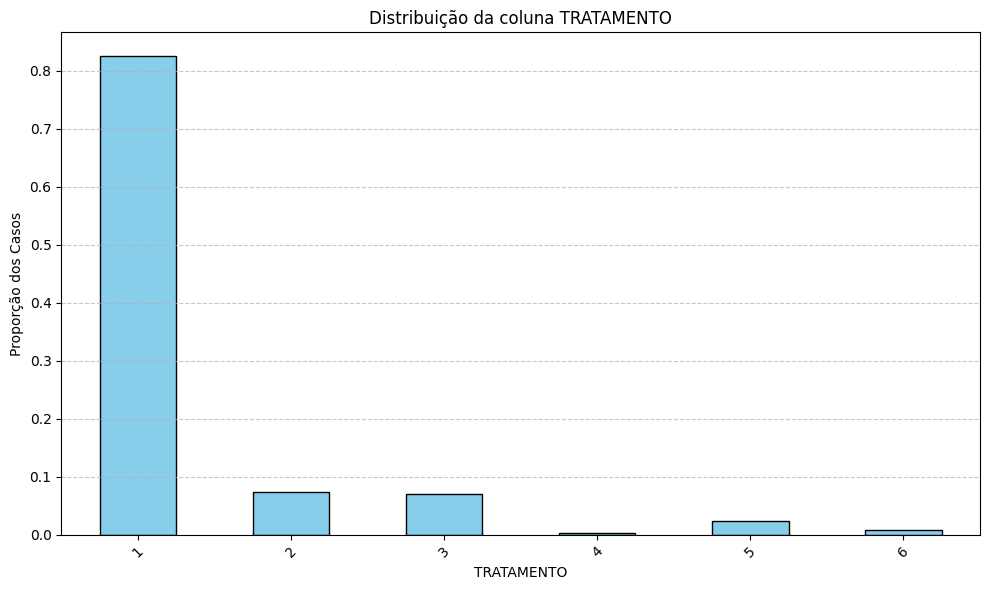

In [248]:
checar_nan(df_cleaned_columns, "TRATAMENTO")

Vamos trabalhar apenas com 1 2 e 3 de **TRATAMENTO**

In [249]:
df_cleaned_columns["TRATAMENTO"] = pd.to_numeric(df_cleaned_columns["TRATAMENTO"], errors="coerce")

df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["TRATAMENTO"].isin([1, 2, 3])]

**FORMA** <br>
1. Pulmonar <br>
2. Extrapulmonar <br>
3. Pulmonar + Extrapulmonar

A coluna 'FORMA' não contém valores NaN.


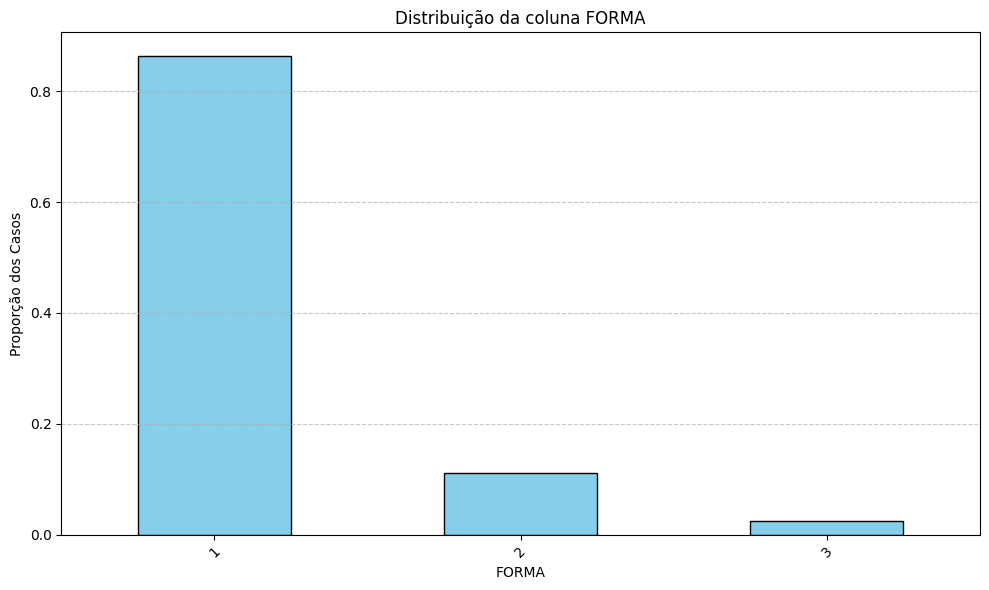

In [250]:
checar_nan(df_cleaned_columns, "FORMA")

Vamos remover apenas a classe 3, que tem apenas de 5%

In [251]:
df_cleaned_columns["FORMA"] = pd.to_numeric(df_cleaned_columns["FORMA"], errors="coerce")

df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["FORMA"].isin([1, 2])]

In [252]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'DT_NOTIFIC', 'NU_ANO', 'DT_DIAG', 'CS_SEXO', 'CS_RACA',
       'ID_MN_RESI', 'ID_RG_RESI', 'DT_DIGITA', 'TRATAMENTO', 'FORMA',
       'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC',
       'AGRAVOUTRA', 'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT', 'DT_NOTI_AT',
       'SG_UF_2', 'TRATSUP_AT', 'NU_COMU_EX', 'DT_ENCERRA', 'TPUNINOT',
       'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV',
       'AGRAVDROGA', 'AGRAVTABAC', 'arquivo', 'SITUACAO_AGRUPADA', 'REGIAO',
       'IDADE_ANOS', 'ESCOL_CATEGORIZADA'],
      dtype='object')

**NU_COMU_EX**<br> 
Total de contatos <br> 
Preencher o total de 
Contatos identificados 
pelo paciente na 
ocasião do diagnóstico 
do caso. <br> 
Campo Obrigatório 

Atenção: A coluna 'NU_COMU_EX' contém 14338 valores NaN.
Isso representa 9.05% do total de 158382 registros.


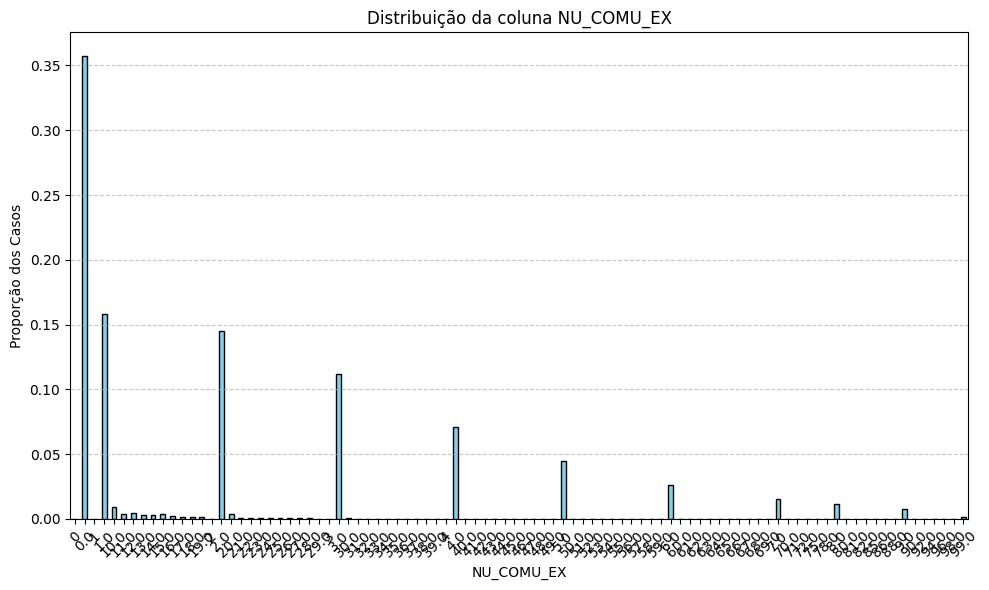

In [253]:
checar_nan(df_cleaned_columns, "NU_COMU_EX")

In [254]:
df_cleaned_columns["NU_COMU_EX"] = pd.to_numeric(df_cleaned_columns["NU_COMU_EX"], errors="coerce").dropna().astype(int)

**AGRAVOS**<br>
AGRAVOS (AGRAVAIDS, AGRAVALCOO, AGRAVDIABE, AGRAVDOENC, AGRAVOUTRA) varchar2(1) <br>
1. Sim <br>
2. Não <br>
9. Ignorado

Atenção: A coluna 'AGRAVAIDS' contém 1881 valores NaN.
Isso representa 1.19% do total de 158382 registros.


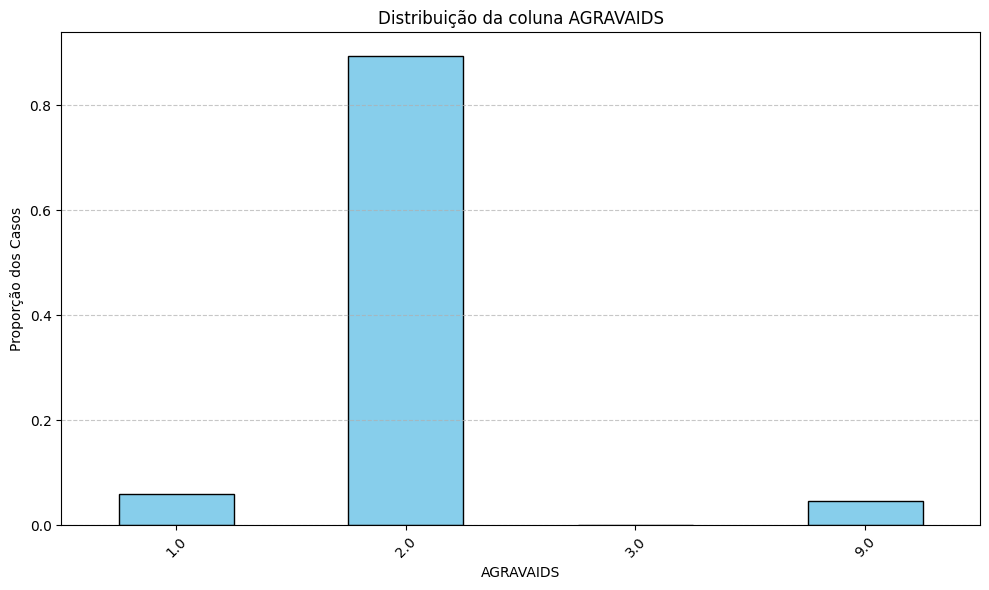

Atenção: A coluna 'AGRAVALCOO' contém 1366 valores NaN.
Isso representa 0.86% do total de 158382 registros.


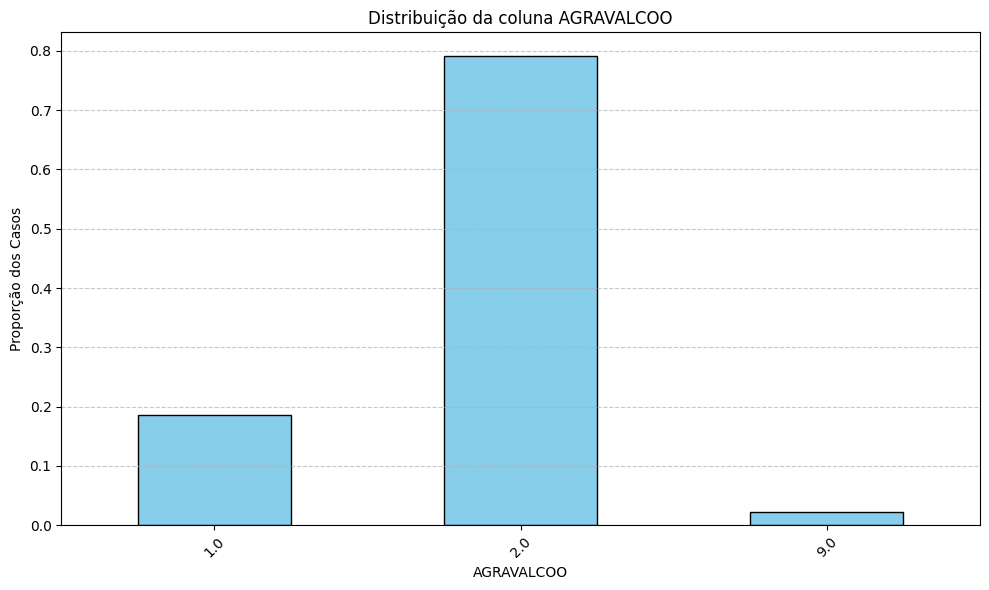

Atenção: A coluna 'AGRAVDIABE' contém 1416 valores NaN.
Isso representa 0.89% do total de 158382 registros.


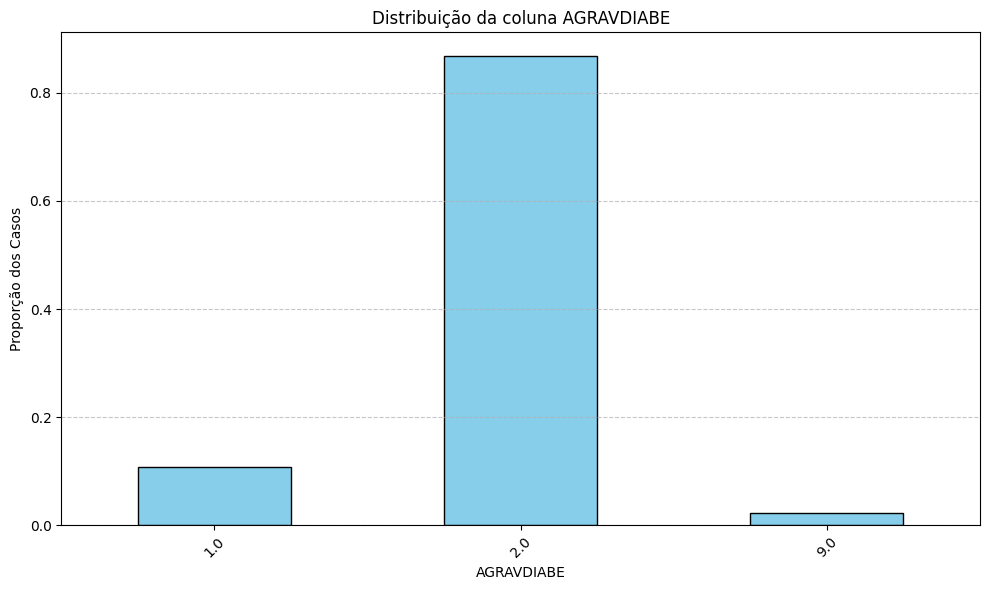

Atenção: A coluna 'AGRAVDOENC' contém 1833 valores NaN.
Isso representa 1.16% do total de 158382 registros.


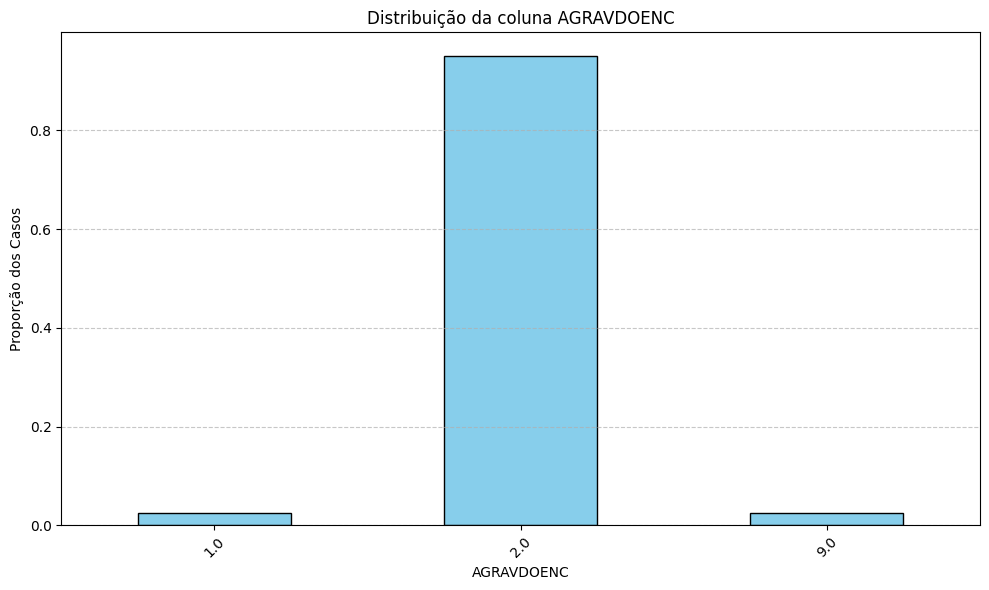

Atenção: A coluna 'AGRAVOUTRA' contém 45499 valores NaN.
Isso representa 28.73% do total de 158382 registros.


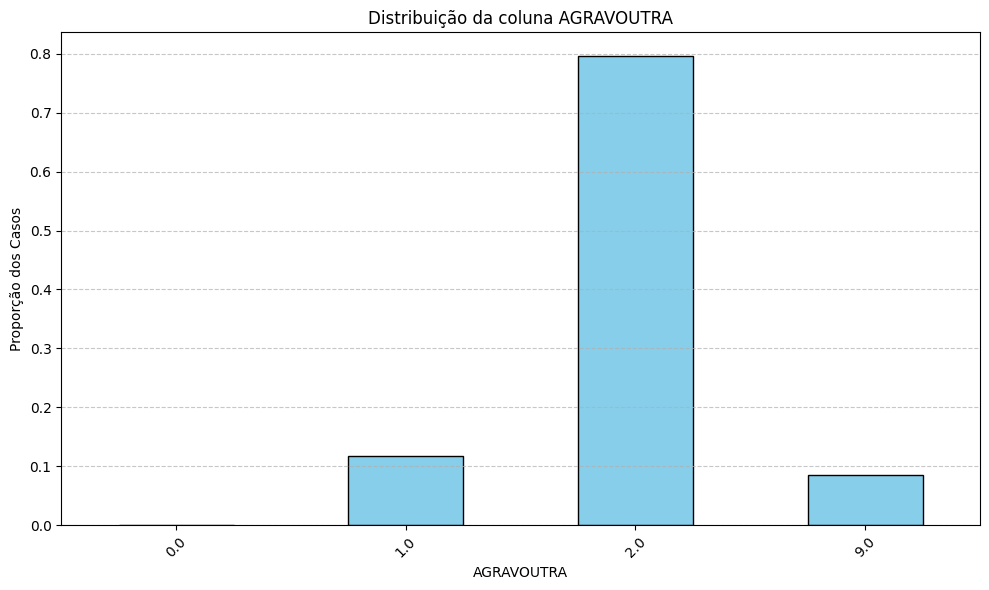

In [255]:
# Lista das colunas a serem removidas
colunas_separadas = [
    'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA'
]

for coluna in colunas_separadas:
    df_cleaned_columns[coluna] = pd.to_numeric(df_cleaned_columns[coluna], errors="coerce")
    checar_nan(df_cleaned_columns, nome_coluna=coluna)

Decidimos remover as anotações que foram colocadas em ignorado, e remover a coluna de **AGRAVOENC**

A coluna 'AGRAVAIDS' não contém valores NaN.


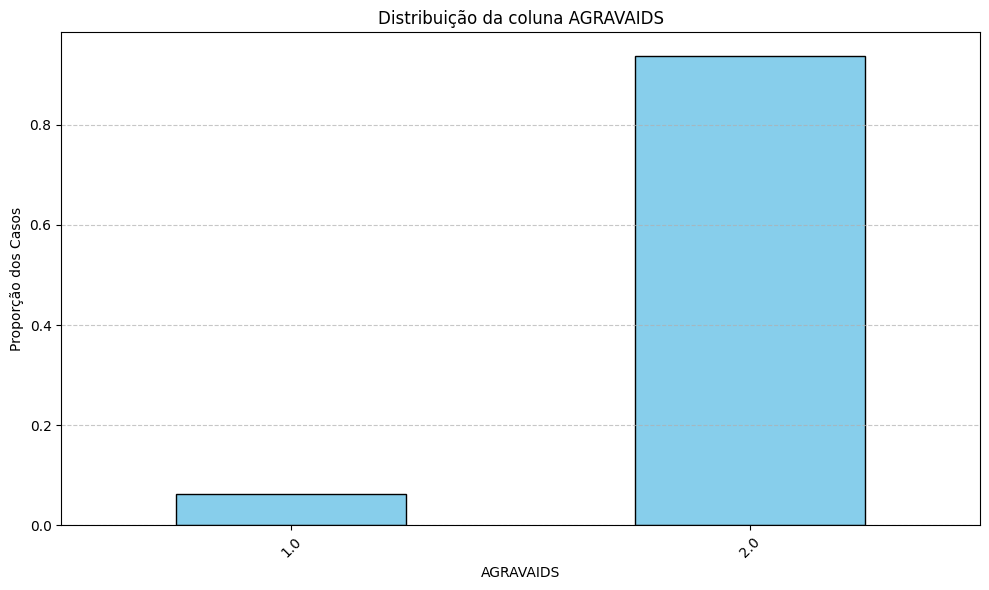

A coluna 'AGRAVALCOO' não contém valores NaN.


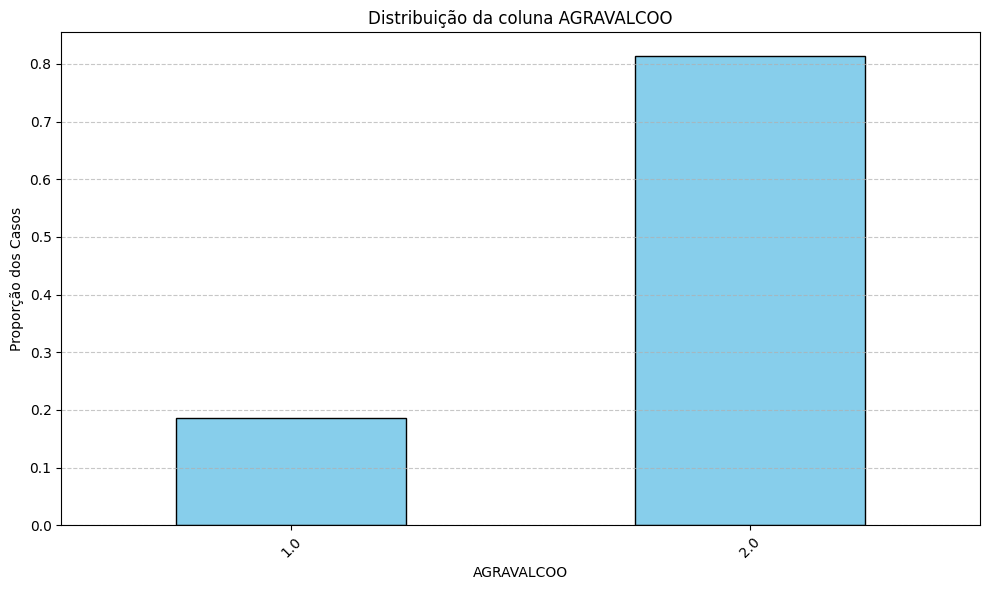

A coluna 'AGRAVDIABE' não contém valores NaN.


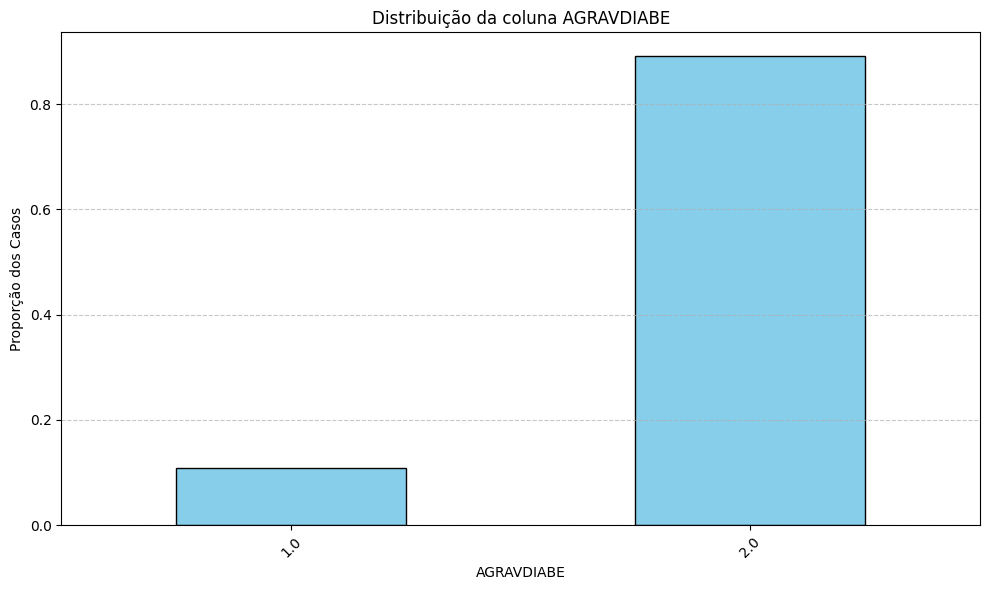

A coluna 'AGRAVDOENC' não contém valores NaN.


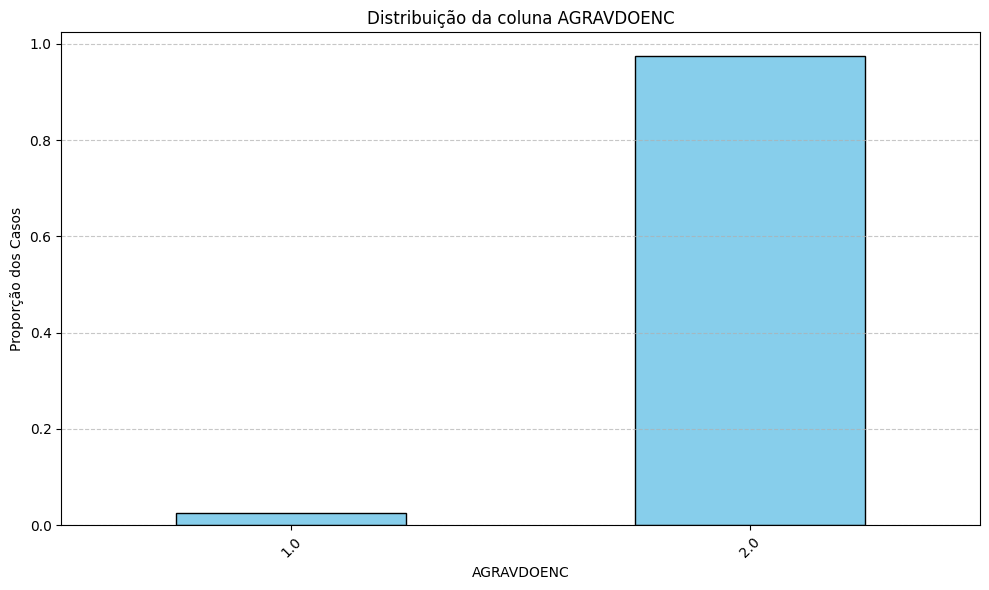

A coluna 'AGRAVOUTRA' não contém valores NaN.


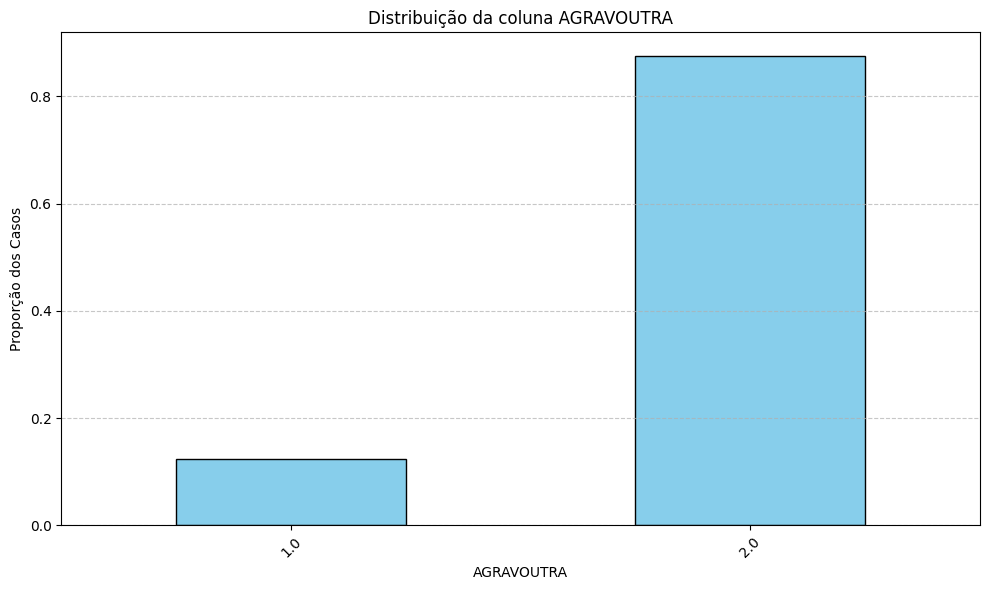

In [256]:
for coluna in colunas_separadas:
    df_cleaned_columns = df_cleaned_columns[df_cleaned_columns[coluna].isin([1, 2])]
    checar_nan(df_cleaned_columns, nome_coluna=coluna)

df_cleaned_columns = df_cleaned_columns.drop(columns=['AGRAVDOENC'])

**TRATSUP_AT**<br>
Tratamento Diretamente Observado (TDO) realizado - varchar2(1): <br>
1- Sim <br>
2- Não <br>
9- Ignorado <br>

Atenção: A coluna 'TRATSUP_AT' contém 17195 valores NaN.
Isso representa 17.53% do total de 98105 registros.


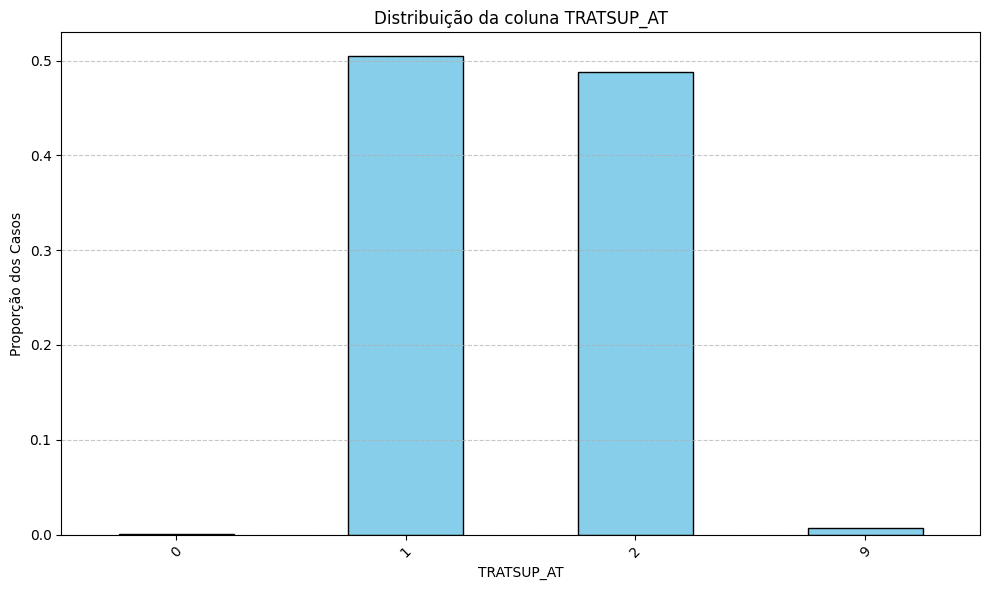

In [257]:
checar_nan(df_cleaned_columns, "TRATSUP_AT")

Vamos pegar apenas os casos de sim e não.

In [258]:
df_cleaned_columns["TRATSUP_AT"] = pd.to_numeric(df_cleaned_columns["TRATSUP_AT"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["TRATSUP_AT"].isin([1, 2])]

In [259]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'DT_NOTIFIC', 'NU_ANO', 'DT_DIAG', 'CS_SEXO', 'CS_RACA',
       'ID_MN_RESI', 'ID_RG_RESI', 'DT_DIGITA', 'TRATAMENTO', 'FORMA',
       'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVOUTRA',
       'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT', 'DT_NOTI_AT', 'SG_UF_2',
       'TRATSUP_AT', 'NU_COMU_EX', 'DT_ENCERRA', 'TPUNINOT', 'POP_LIBER',
       'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV', 'AGRAVDROGA',
       'AGRAVTABAC', 'arquivo', 'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS',
       'ESCOL_CATEGORIZADA'],
      dtype='object')

Agora, vamos olhar as colunas que faltam que tenham muitos termos diferentes para a mesma coluna

Sobraram três variáveis de datas relevantes:<br> <br>
**DT_DIAG:** Data da notificação ao profissional da saúde<br>
**DT_NOTIFIC:** Data da Notificação Atual <br>
**DT_INIC_TR:** Data de inicio de tratamento <br>
**DT_ENCERRA:** Data de encerramento<br><br>
**DT_DIGITA:** SEM DOCUMENTAÇÃO

Vamos apagar **DT_DIGITA**, por não ter in formações sobre

In [260]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_DIGITA'])

Agora vamos apagar as variáveis de data para dar lugar a novas quatro colunas:
<br>TEMPO_DE_NOTI: Tempo entre os primeiros sintomas e a notificação
<br>TEMPO_DE_ENCERRA: Tempo entre os primeiros sintomas e o encerramento
<br>TEMPO_DE_TRATAMENTO: Tempo entre o inicio e fim do tratamento
<br>TEMPO_DE_INICIO_TRATAMENTO: Tempo entre os primeiros sintomas e o inicio do tratamento

In [261]:
df_cleaned_columns['DT_DIAG'] = pd.to_datetime(df_cleaned_columns['DT_DIAG'], errors='coerce')
df_cleaned_columns['DT_NOTIFIC'] = pd.to_datetime(df_cleaned_columns['DT_NOTIFIC'], errors='coerce')
df_cleaned_columns['DT_ENCERRA'] = pd.to_datetime(df_cleaned_columns['DT_ENCERRA'], errors='coerce')
df_cleaned_columns['DT_INIC_TR'] = pd.to_datetime(df_cleaned_columns['DT_INIC_TR'], errors='coerce')

df_cleaned_columns['TEMPO_DE_NOTI'] = (df_cleaned_columns['DT_NOTIFIC'] - df_cleaned_columns['DT_DIAG']).dt.days
df_cleaned_columns['TEMPO_DE_ENCERRA'] = (df_cleaned_columns['DT_ENCERRA'] - df_cleaned_columns['DT_DIAG']).dt.days
df_cleaned_columns['TEMPO_DE_TRATAMENTO'] = (df_cleaned_columns['DT_ENCERRA'] - df_cleaned_columns['DT_INIC_TR']).dt.days
df_cleaned_columns['TEMPO_DE_INICIO_TRATAMENTO'] = (df_cleaned_columns['DT_INIC_TR'] - df_cleaned_columns['DT_DIAG']).dt.days

A coluna 'TEMPO_DE_NOTI' não contém valores NaN.


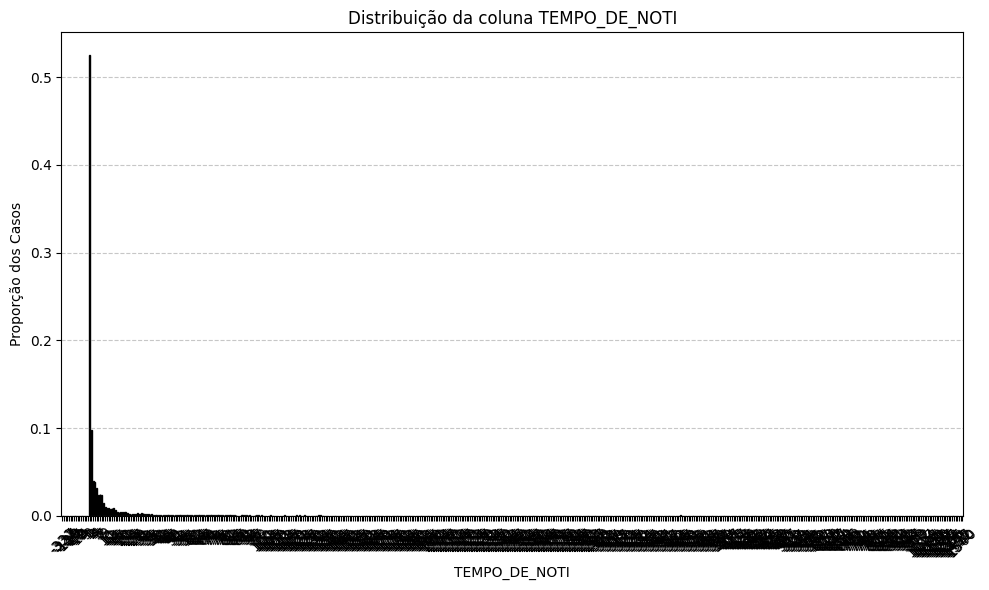

Atenção: A coluna 'TEMPO_DE_ENCERRA' contém 581 valores NaN.
Isso representa 0.72% do total de 80347 registros.


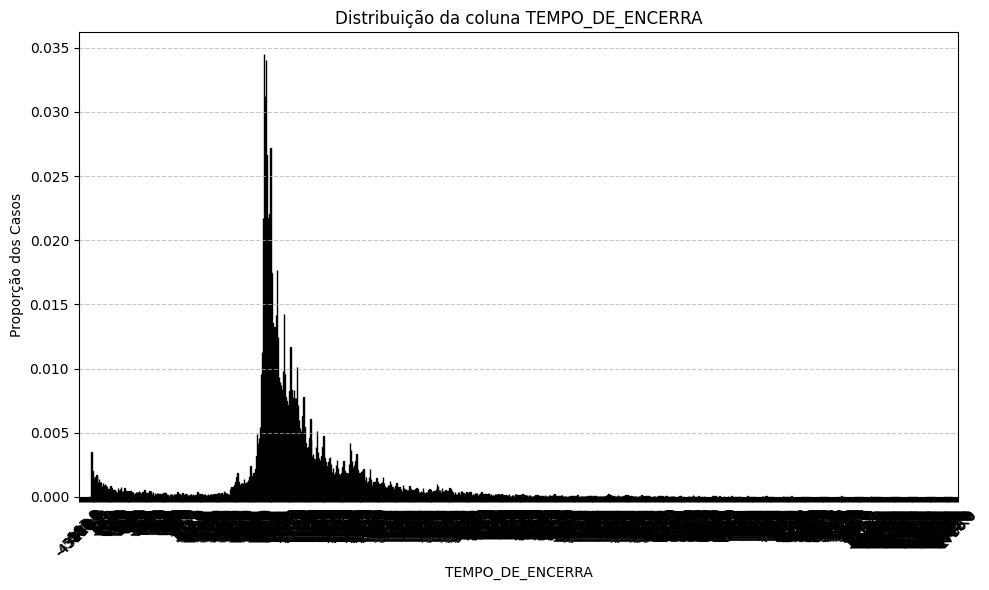

Atenção: A coluna 'TEMPO_DE_TRATAMENTO' contém 1763 valores NaN.
Isso representa 2.19% do total de 80347 registros.


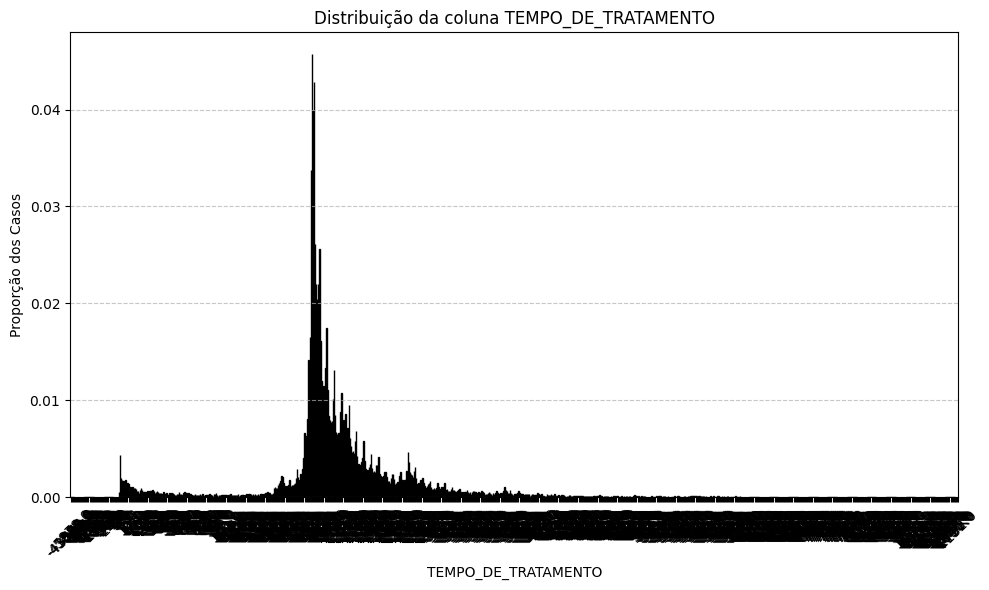

Atenção: A coluna 'TEMPO_DE_INICIO_TRATAMENTO' contém 1204 valores NaN.
Isso representa 1.50% do total de 80347 registros.


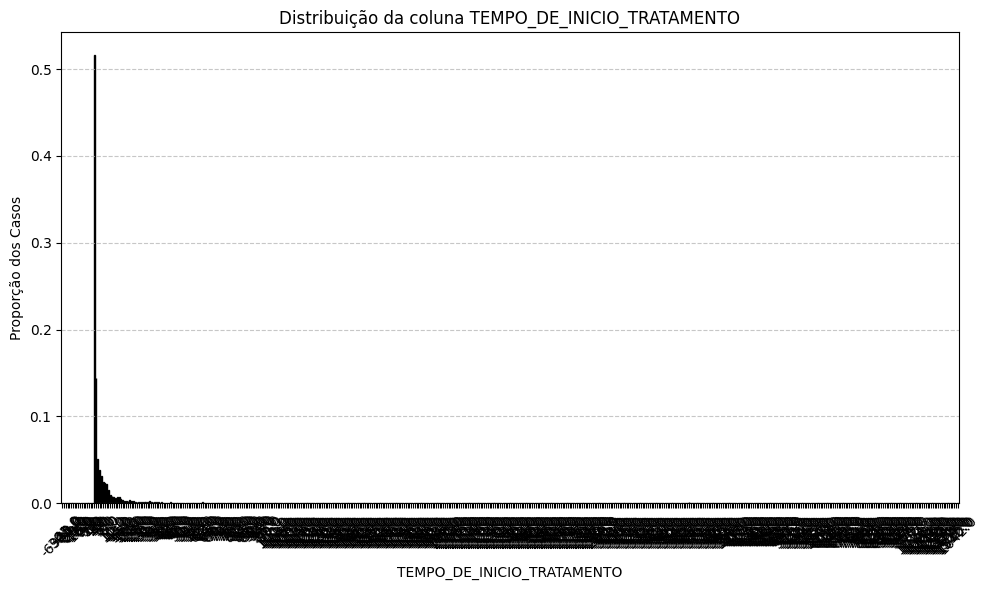

In [262]:
colunas_separadas = [
    'TEMPO_DE_NOTI', 'TEMPO_DE_ENCERRA', 'TEMPO_DE_TRATAMENTO', 'TEMPO_DE_INICIO_TRATAMENTO'
]

for coluna in colunas_separadas:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)

Aqui apagamos as datas:

In [263]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_DIAG'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_NOTIFIC'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_ENCERRA'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['DT_INIC_TR'])

Vamos remover as seguintes colunas por redundância (existem já colunas equivalentes): **SG_UF_2** **SG_UF_AT** **DT_NOTI_AT**

Atenção: A coluna 'SG_UF_2' contém 477 valores NaN.
Isso representa 0.59% do total de 80347 registros.


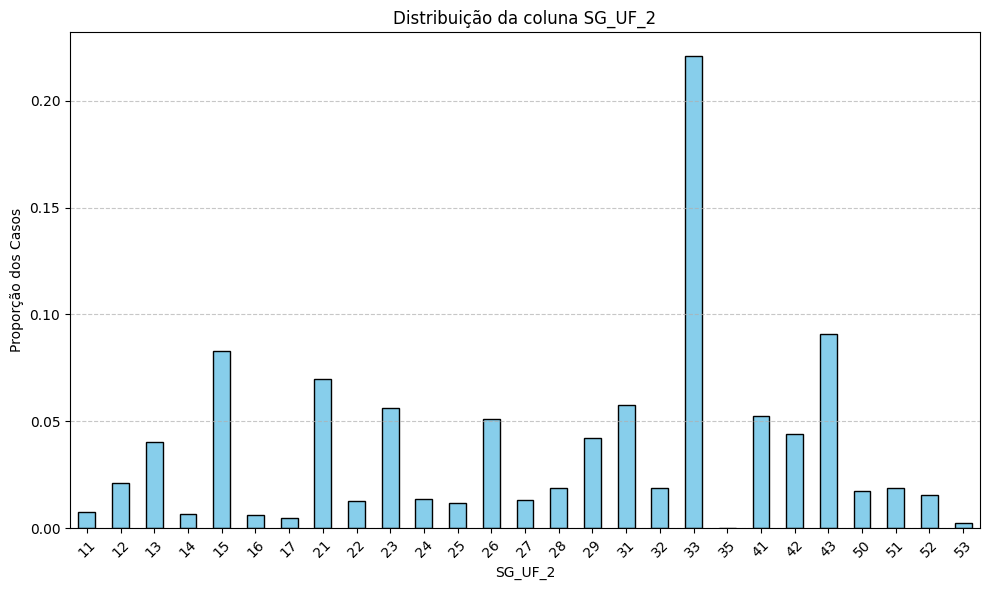

Atenção: A coluna 'SG_UF_AT' contém 82 valores NaN.
Isso representa 0.10% do total de 80347 registros.


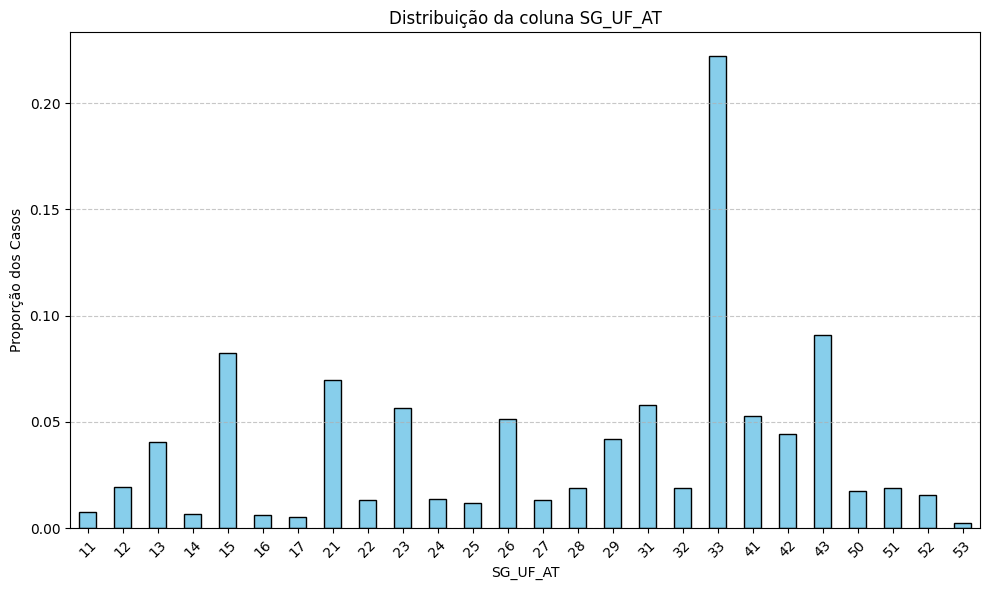

Atenção: A coluna 'DT_NOTI_AT' contém 82 valores NaN.
Isso representa 0.10% do total de 80347 registros.


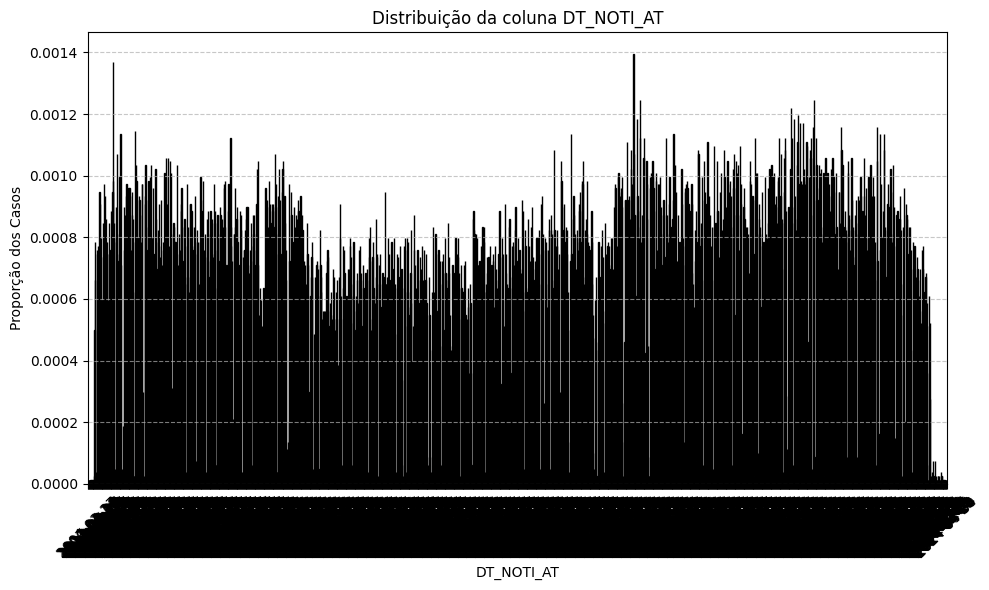

In [264]:
# Lista das colunas a serem removidas
colunas_separadas = [
    'SG_UF_2', 'SG_UF_AT', 'DT_NOTI_AT'
]

for coluna in colunas_separadas:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)
    df_cleaned_columns = df_cleaned_columns.drop(columns=[coluna])
    

Vamos remover as seguintes colunas por não ter documentação ou ser baseado em índices irrelevantes: **ID_RG_RESI** **ID_MN_RESI** **EXTRAPU1_N** **arquivo**, **TPUNINOT**

Atenção: A coluna 'ID_RG_RESI' contém 21446 valores NaN.
Isso representa 26.69% do total de 80347 registros.


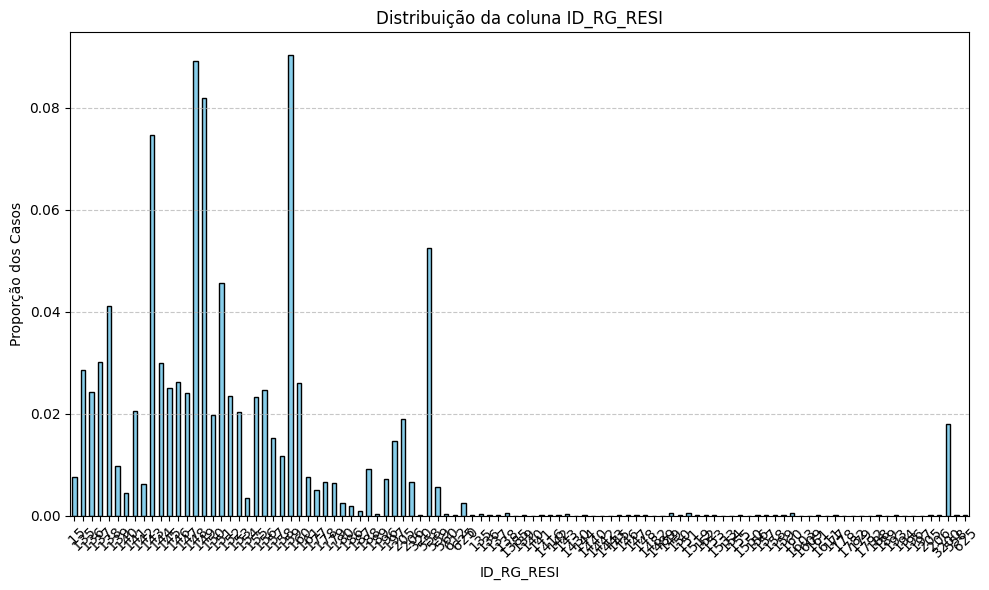

A coluna 'ID_MN_RESI' não contém valores NaN.


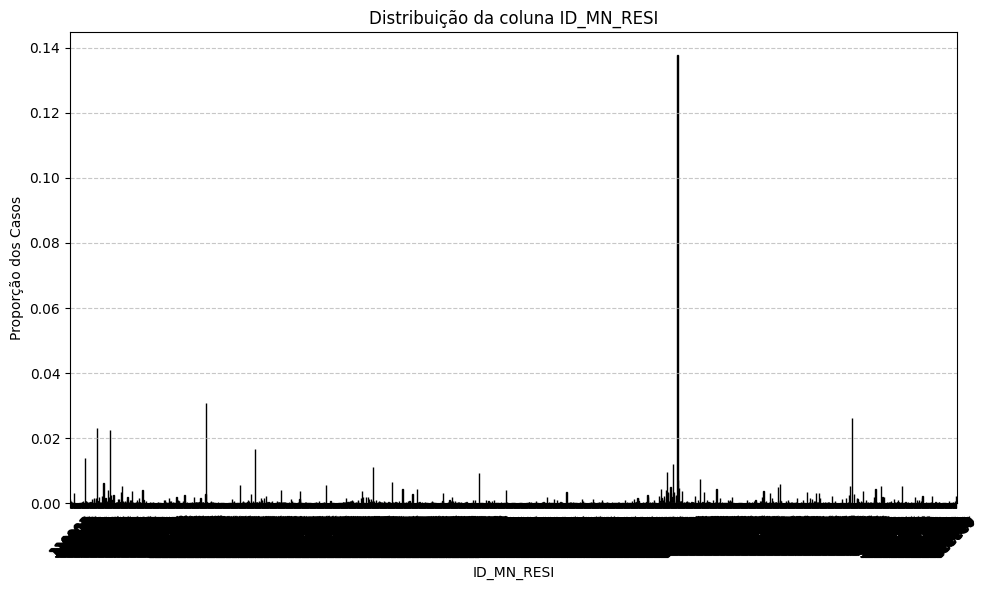

Atenção: A coluna 'EXTRAPU1_N' contém 345 valores NaN.
Isso representa 0.43% do total de 80347 registros.


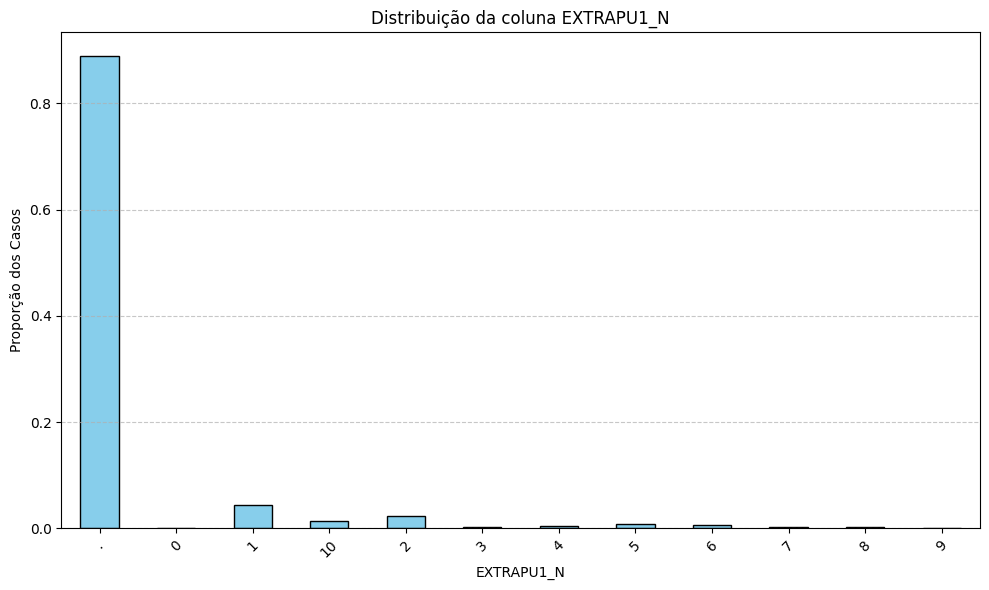

A coluna 'arquivo' não contém valores NaN.


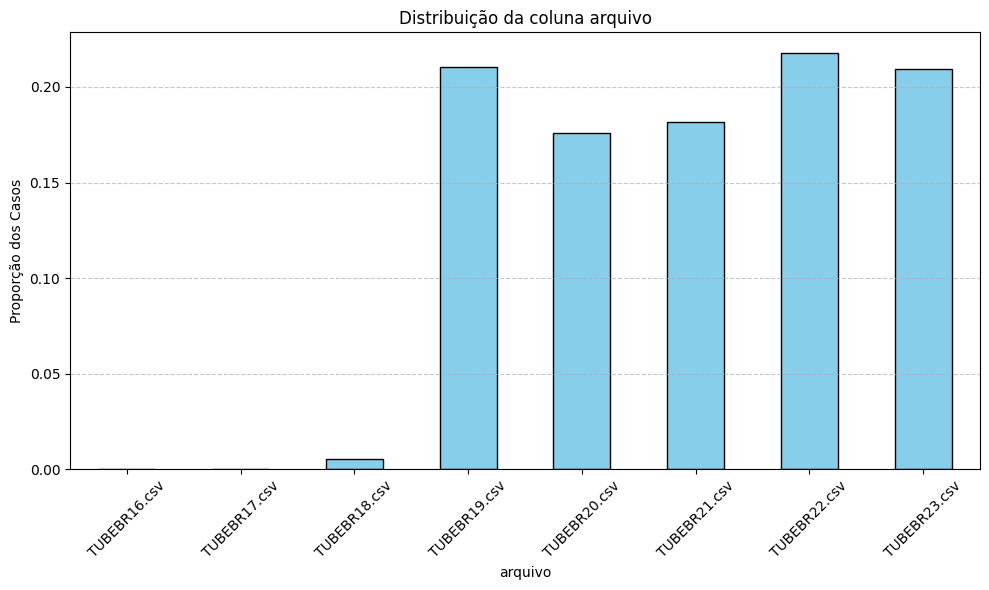

Atenção: A coluna 'TPUNINOT' contém 2773 valores NaN.
Isso representa 3.45% do total de 80347 registros.


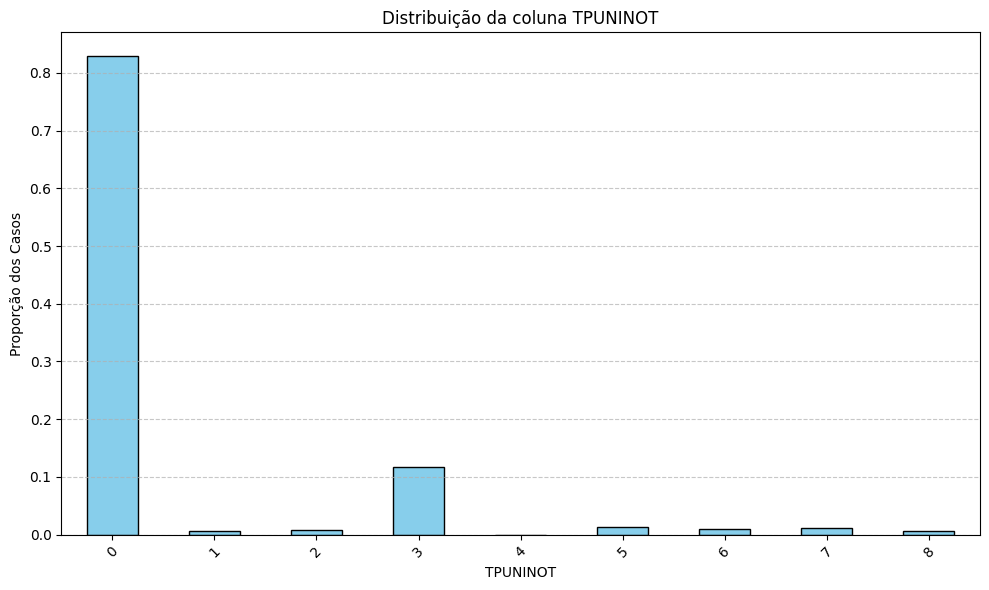

In [265]:
# Lista das colunas a serem removidas
colunas_separadas = [
    'ID_RG_RESI', 'ID_MN_RESI', 'EXTRAPU1_N', 'arquivo', 'TPUNINOT'
]

for coluna in colunas_separadas:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)
    df_cleaned_columns = df_cleaned_columns.drop(columns=[coluna])

**Populações Especiais ('POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG')**, <br>
 Beneficiários de programas do governo (BENEF_GOV) <br>
 varchar2(1): <br>
1- Sim <br>
2- Não <br>
9- Ignorado

Atenção: A coluna 'POP_LIBER' contém 654 valores NaN.
Isso representa 0.81% do total de 80347 registros.


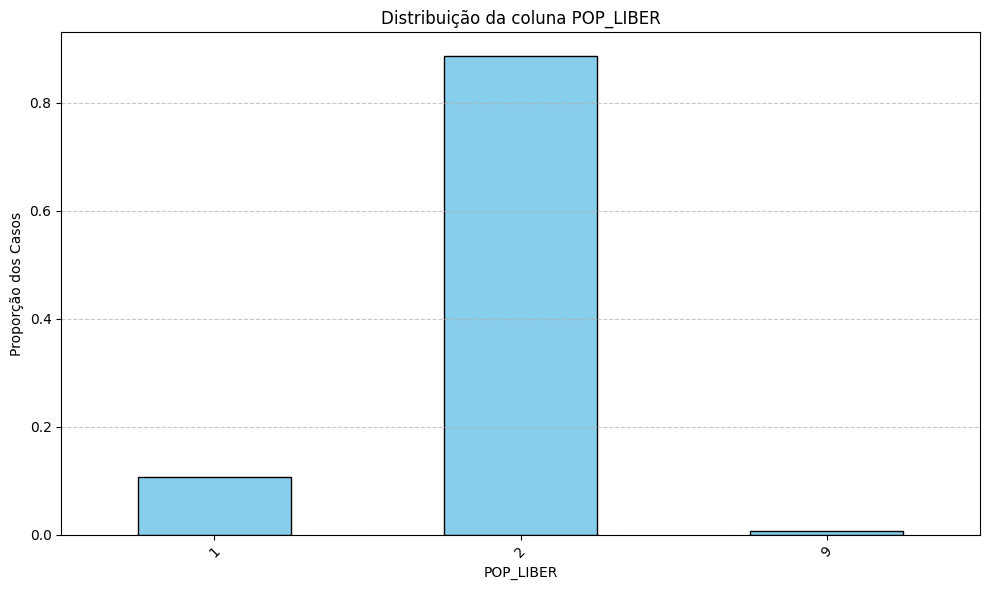

Atenção: A coluna 'POP_RUA' contém 754 valores NaN.
Isso representa 0.94% do total de 80347 registros.


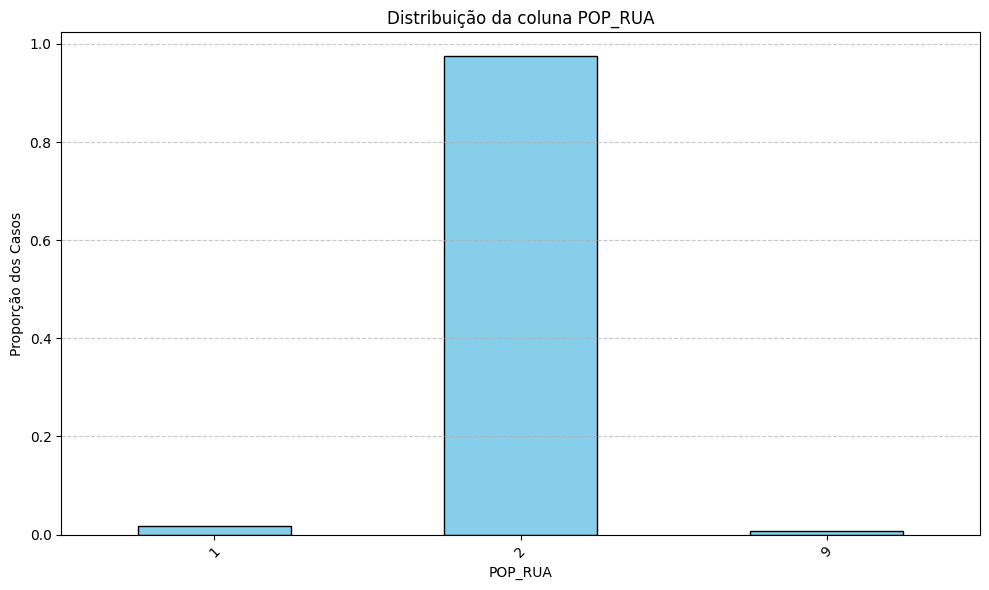

Atenção: A coluna 'POP_SAUDE' contém 735 valores NaN.
Isso representa 0.91% do total de 80347 registros.


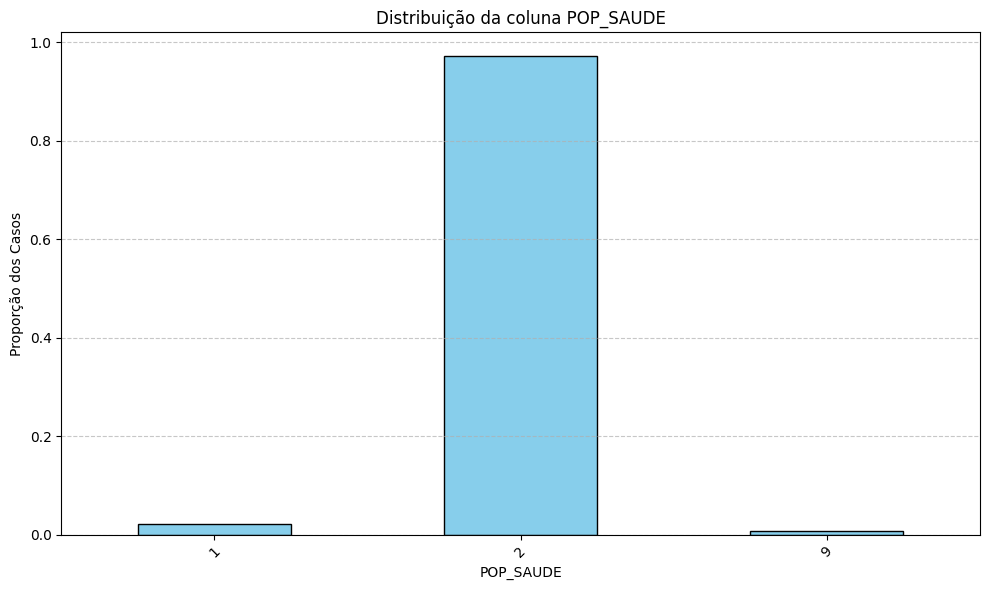

Atenção: A coluna 'POP_IMIG' contém 781 valores NaN.
Isso representa 0.97% do total de 80347 registros.


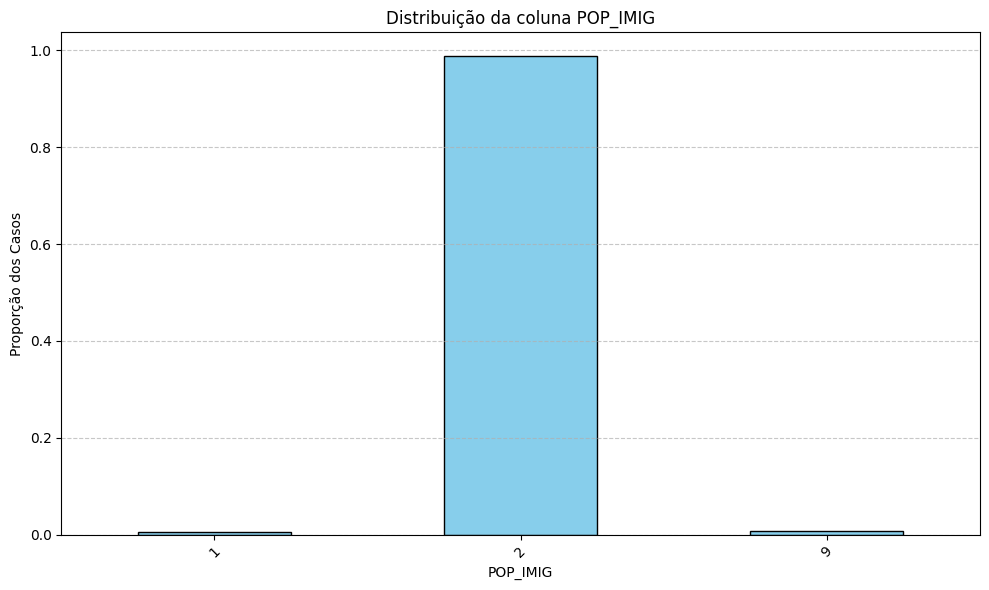

Atenção: A coluna 'BENEF_GOV' contém 1644 valores NaN.
Isso representa 2.05% do total de 80347 registros.


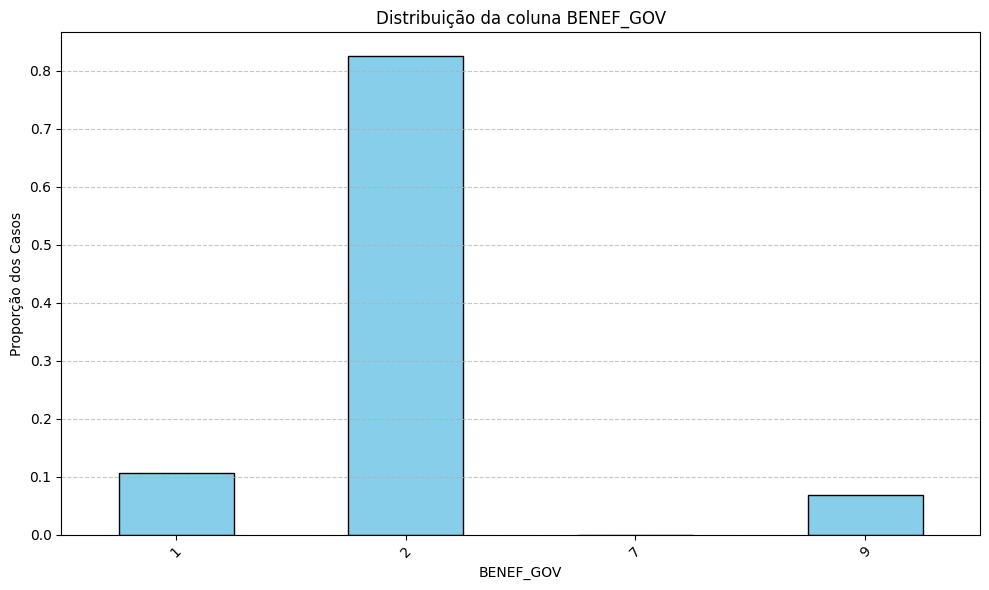

In [266]:
colunas_separadas = [
    'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV'
]

for coluna in colunas_separadas:
    checar_nan(df_cleaned_columns, nome_coluna=coluna)

As populações em geral tem pouquissimas amostras, vamos usar apenas **POP_LIBER** e **BENEF_GOV**

In [267]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['POP_IMIG'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['POP_RUA'])
df_cleaned_columns = df_cleaned_columns.drop(columns=['POP_SAUDE'])

In [268]:
df_cleaned_columns["POP_LIBER"] = pd.to_numeric(df_cleaned_columns["POP_LIBER"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["POP_LIBER"].isin([1, 2])]

df_cleaned_columns["BENEF_GOV"] = pd.to_numeric(df_cleaned_columns["BENEF_GOV"], errors="coerce")
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["BENEF_GOV"].isin([1, 2])]

OUTROS AGRAVOS (AGRAVDROGA, AGRAVTABAC) varchar2(1) <br>
1. Sim <br>
2. Não <br>
9. Ignorado

In [269]:
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["AGRAVDROGA"].isin(['1', '2'])]
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["AGRAVTABAC"].isin(['1', '2'])]

In [270]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'NU_ANO', 'CS_SEXO', 'CS_RACA', 'TRATAMENTO', 'FORMA',
       'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVOUTRA', 'NU_CONTATO',
       'TRATSUP_AT', 'NU_COMU_EX', 'POP_LIBER', 'BENEF_GOV', 'AGRAVDROGA',
       'AGRAVTABAC', 'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS',
       'ESCOL_CATEGORIZADA', 'TEMPO_DE_NOTI', 'TEMPO_DE_ENCERRA',
       'TEMPO_DE_TRATAMENTO', 'TEMPO_DE_INICIO_TRATAMENTO'],
      dtype='object')

### Agora vamos separar em variáveis de classificação e de regressão:

In [271]:
classificacao = ['CS_SEXO', 'CS_RACA', 'TRATAMENTO', 'FORMA', 'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVOUTRA',
                 'TRATSUP_AT', 'POP_LIBER', 'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC', 'REGIAO', 'ESCOL_CATEGORIZADA']

In [272]:
regressao = ['NU_ANO', 'NU_CONTATO', 'IDADE_ANOS', 'TEMPO_DE_NOTI', 'TEMPO_DE_ENCERRA', 'TEMPO_DE_TRATAMENTO', 'TEMPO_DE_INICIO_TRATAMENTO']

In [273]:
df_encoded = pd.get_dummies(df_cleaned_columns, columns=classificacao)

In [274]:
y = df_encoded['SITUACAO_AGRUPADA']
X = df_encoded.drop(columns=['SITUACAO_AGRUPADA'])


In [275]:
n_max = 21000
np.random.seed(42)
amostra_indices = np.random.choice(X.index, size=min(n_max, len(X)), replace=False)

X_amostra = X.loc[amostra_indices]
y_amostra = y.loc[amostra_indices]

In [276]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_amostra,
    y_amostra,
    test_size=0.2,
    stratify=y_amostra,
    random_state=42
)

In [277]:
print(f"Treino: {X_train.shape[0]} instâncias")
print(f"Teste: {X_test.shape[0]} instâncias\n")

print("Distribuição das classes no treino:")
print(y_train.value_counts(normalize=True), '\n')

print("Distribuição das classes no teste:")
print(y_test.value_counts(normalize=True))


Treino: 16800 instâncias
Teste: 4200 instâncias

Distribuição das classes no treino:
SITUACAO_AGRUPADA
0    0.96625
1    0.03375
Name: proportion, dtype: float64 

Distribuição das classes no teste:
SITUACAO_AGRUPADA
0    0.96619
1    0.03381
Name: proportion, dtype: float64


In [278]:
pd.concat([X_train, y_train], axis=1).to_csv("dados_treino.csv", index=False)
pd.concat([X_test, y_test], axis=1).to_csv("dados_teste.csv", index=False)